# Machine Learning-Based Cross-Sectional Stock Selection for the S&P 500

**MSE 623 Final Project**

**Team:** Chenyu Liu · Yi Lu · Yukang Luo

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Data Loading |
| 2 | Data Preprocessing |
| 3 | Feature Engineering (12 technical indicators) |
| 4 | Monthly Feature Dataset + Cross-Sectional Standardization (z-score) |
| 5 | Target Construction (3-month forward return + binary label) |
| 6 | Expanding-Window Cross-Validation (LR / RF / XGBoost — all Classification) |
| 7 | Final Out-of-Sample Testing (2017) |
| 8 | Ensemble Model (rank-averaged scores) |
| 9 | Portfolio Construction & Evaluation (month-by-month) |
| 10 | Robustness Analysis |

**Formation period:** All calendar months, 2013–2017
**Prediction target:** Binary cross-sectional label (top 20% within each month for training; portfolio selects top 10%)
**Features:** 12 technical indicators, cross-sectionally standardized (z-scored) within each formation month
**Models:** Logistic Regression · Random Forest · XGBoost · Rank-Ensemble (all classification)
**Portfolio:** Equal-weighted top-10% long vs equal-weighted S&P 500 benchmark; long-short strategy using top-10% minus bottom-10% (constructed month-by-month)

## Step 1: Imports & Configuration

In [61]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [62]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier          # Classification task
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost: available')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost: not installed – skipping XGBoost section')

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
np.random.seed(42)

print('All libraries loaded.')

XGBoost: available
All libraries loaded.


## Step 2: Data Loading

We load all individual stock CSV files from the local archive.
Each file contains daily OHLCV data for one S&P 500 constituent (Feb 2013 – Feb 2018).

In [63]:

SCRIPT_DIR = os.getcwd()
DATA_PATH = os.path.join(SCRIPT_DIR, 'archive', 'individual_stocks_5yr')
OUT_DIR = SCRIPT_DIR

all_data = []
for file in sorted(os.listdir(DATA_PATH)):
    if file.endswith('.csv'):
        try:
            df = pd.read_csv(os.path.join(DATA_PATH, file))
            all_data.append(df)
        except Exception as e:
            print(f'  Warning: Could not load {file}: {e}')

data = pd.concat(all_data, ignore_index=True)
data.columns = [c.lower().strip() for c in data.columns]
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['name', 'date']).reset_index(drop=True)

print('=== Dataset Overview ===')
print(f'Total records  : {len(data):,}')
print(f'Unique tickers : {data["name"].nunique()}')
print(f'Date range     : {data["date"].min().date()} to {data["date"].max().date()}')
print(f'Columns        : {list(data.columns)}')
data.head()

=== Dataset Overview ===
Total records  : 619,040
Unique tickers : 505
Date range     : 2013-02-08 to 2018-02-07
Columns        : ['date', 'open', 'high', 'low', 'close', 'volume', 'name']


,date,open,high,low,close,volume,name
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A


In [64]:
# Data availability: unique tickers per year-month (pivot table)
ym = (data.assign(year=data['date'].dt.year, month=data['date'].dt.month)
         .groupby(['year', 'month'])['name'].nunique()
         .unstack('month'))
ym.columns = [f'M{m:02d}' for m in ym.columns]
print('Tickers with data per year-month (rows=year, cols=month):')
print(ym.to_string())
print(f'\nTotal year-month slices available: {int((ym > 0).sum().sum())}')

Tickers with data per year-month (rows=year, cols=month):
        M01    M02    M03    M04    M05    M06    M07    M08    M09    M10    M11    M12
year                                                                                    
2013    NaN  476.0  476.0  476.0  477.0  482.0  482.0  482.0  482.0  482.0  483.0  483.0
2014  483.0  483.0  484.0  485.0  485.0  486.0  487.0  487.0  488.0  488.0  488.0  488.0
2015  489.0  489.0  489.0  489.0  489.0  490.0  492.0  492.0  492.0  494.0  495.0  495.0
2016  496.0  496.0  496.0  497.0  497.0  497.0  498.0  498.0  498.0  498.0  498.0  499.0
2017  500.0  500.0  500.0  501.0  501.0  501.0  503.0  503.0  504.0  504.0  504.0  505.0
2018  505.0  505.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN

Total year-month slices available: 61


## Step 3: Data Preprocessing

- Remove rows with missing OHLCV values
- Remove rows with zero or negative prices / volume

In [65]:
print('Missing values before cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

data.dropna(subset=['open','high','low','close','volume'], inplace=True)
data = data[(data['close'] > 0) & (data['volume'] > 0) &
            (data['high'] > 0)  & (data['low'] > 0)].copy()
data.reset_index(drop=True, inplace=True)

print(f'\nRecords after cleaning: {len(data):,}')
print('Missing values after cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

Missing values before cleaning:
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Records after cleaning: 619,029
Missing values after cleaning:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


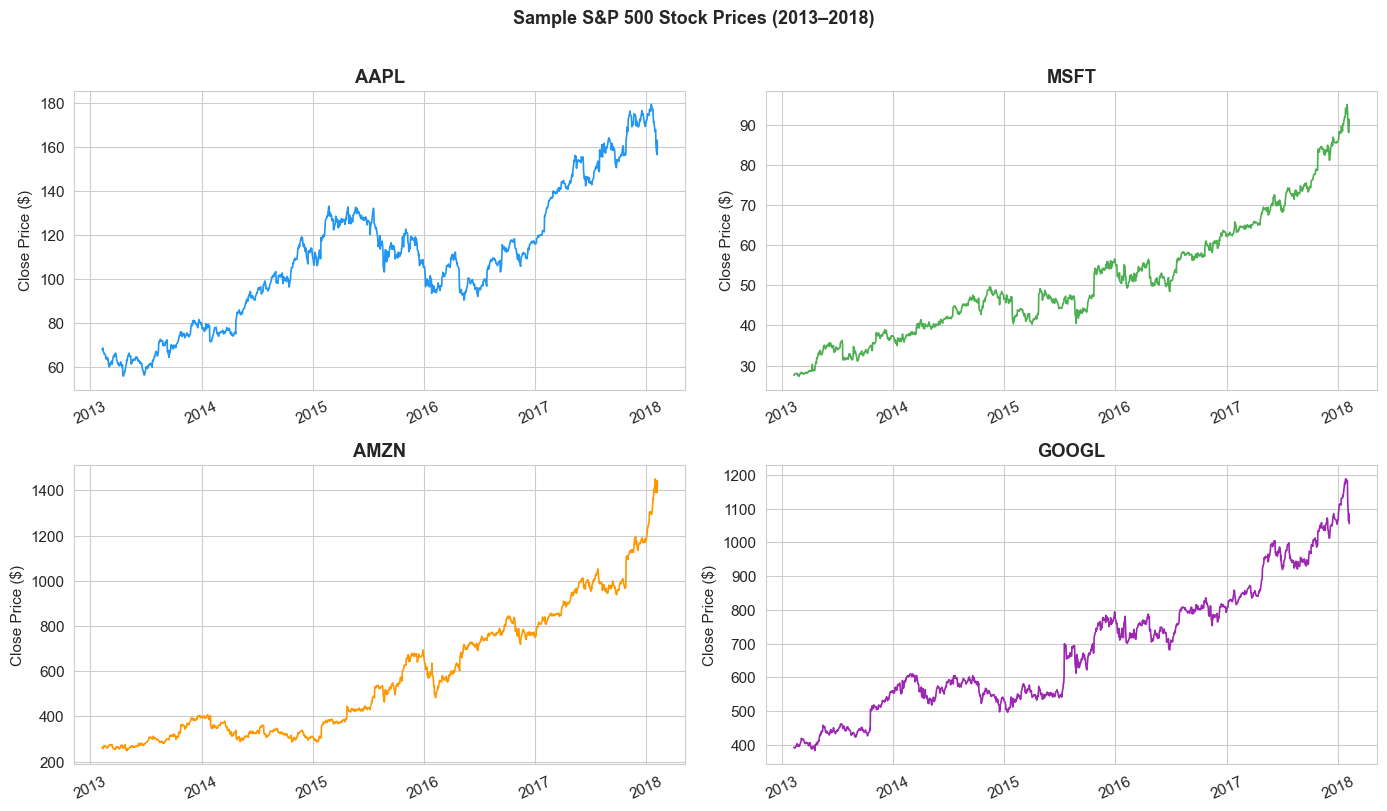

Saved: price_history.png


In [66]:
# Sample stock price histories
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, ticker, color in zip(axes.flat, sample_tickers, colors):
    stock = data[data['name'] == ticker]
    ax.plot(stock['date'], stock['close'], color=color, linewidth=1.2)
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('Close Price ($)')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Sample S&P 500 Stock Prices (2013–2018)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_history.png', bbox_inches='tight')
plt.show()
print('Saved: price_history.png')

## Step 4: Feature Engineering

We compute **12 technical indicators** at the **last trading day of each calendar month**.
All features are built solely from historical OHLCV data up to the formation date (no look-ahead).

| # | Feature | Definition |
|---|---------|-----------|
| 1 | `Momentum_1M` | Return over past 22 trading days |
| 2 | `Momentum_3M` | Return over past 64 trading days |
| 3 | `Price_to_MA20` | Close / 20-day moving average |
| 4 | `MA_20_slope` | OLS slope of the 20-day MA series |
| 5 | `Volatility_20d` | Std dev of 20-day daily returns |
| 6 | `High_Low_Range` | Day's High / Day's Low |
| 7 | `Volume_Ratio` | Day's volume / 20-day average volume |
| 8 | `1M_Accum_Vol_Change` | (Sum vol last 21d − prev 21d) / prev 21d |
| 9 | `RSI_14` | 14-day Relative Strength Index, normalised to [0, 1] |
| 10 | `BB_Position` | Bollinger Band position: (price − lower) / (upper − lower) |
| 11 | `High_52W_Ratio` | Close / 52-week high |
| 12 | `Short_Rev` | Negative of 1-week return (short-term reversal) |

After construction, each feature is **cross-sectionally ranked** within its formation month
(percentile rank 0–1 among all stocks in the same month), removing time-series level shifts.

In [67]:
FEATURE_COLS = [
    'Momentum_1M', 'Momentum_3M', 'Momentum_6M',   # momentum at 1/3/6 months
    'Short_Rev',                                     # short-term reversal (1-week)
    'Price_to_MA20', 'Price_to_MA60',               # price vs short/medium MA
    'Volatility_20d', 'Volatility_60d',             # realised vol at 20/60 days
    'Volume_Ratio', '1M_Accum_Vol_Change',          # volume signal
    'High_52W_Ratio',                               # 52-week high proximity
]


def _add_months(year, month, n):
    """Return (year, month) shifted forward by n calendar months."""
    m = month + n
    y = year + (m - 1) // 12
    m = (m - 1) % 12 + 1
    return y, m


def compute_features_for_stock_month(stock_df, year, month, min_history=127):
    """
    Compute 11 technical features at month-end for a given (year, month).

    TARGET CHANGE: Next_Return is now the 3-month forward cumulative return,
    i.e. (close at end of month+3) / (close at end of formation month) - 1.

    No look-ahead bias:
    - Features use strictly data up to the last trading day of `month`.
    - Label is derived from future data (month+1 through end of month+3).
    - The two windows do not overlap.

    Returns a feature dict or None if data is insufficient.
    """
    form_days = stock_df[
        (stock_df['date'].dt.year == year) & (stock_df['date'].dt.month == month)]

    # ── 3-month forward target window ─────────────────────────────────────────
    # Find last trading day close of month+3; used only for the label.
    tgt_year, tgt_month = _add_months(year, month, 3)
    tgt_days = stock_df[
        (stock_df['date'].dt.year == tgt_year) & (stock_df['date'].dt.month == tgt_month)]

    if len(form_days) < 10 or len(tgt_days) < 10:
        return None

    last_form_date    = form_days['date'].max()
    last_form_row     = form_days.loc[form_days['date'] == last_form_date].iloc[0]
    last_target_close = tgt_days.loc[
        tgt_days['date'] == tgt_days['date'].max(), 'close'].values[0]

    # Historical data strictly up to (and including) last_form_date — no look-ahead
    hist = stock_df[stock_df['date'] <= last_form_date].copy()
    if len(hist) < min_history:
        return None

    closes  = hist['close'].values.astype(float)
    volumes = hist['volume'].values.astype(float)

    if np.any(closes <= 0) or np.any(volumes <= 0):
        return None
    if len(closes) < 126 or len(volumes) < 42:
        return None

    daily_rets = closes[1:] / closes[:-1] - 1

    # ── Momentum features ─────────────────────────────────────────────────────
    # 1M momentum: cumulative return over last 22 trading days
    momentum_1m = (closes[-1] / closes[-22]) - 1
    # 3M momentum: cumulative return over last 64 trading days
    momentum_3m = (closes[-1] / closes[-64]) - 1
    # 6M momentum: cumulative return over last 126 trading days (medium-horizon trend)
    momentum_6m = (closes[-1] / closes[-126]) - 1
    # Short-term reversal: negative of 1-week return (mean-reversion signal)
    short_rev   = -((closes[-1] / closes[-6]) - 1) if len(closes) >= 6 else 0.0

    # ── Price / moving-average features ──────────────────────────────────────
    # Price relative to 20-day MA: short-term trend position
    ma20          = np.mean(closes[-20:])
    price_to_ma20 = closes[-1] / ma20
    # Price relative to 60-day MA: medium-term trend position (new)
    ma60          = np.mean(closes[-60:])
    price_to_ma60 = closes[-1] / ma60

    # ── Volatility features ───────────────────────────────────────────────────
    # 20-day realised volatility (std of daily returns)
    volatility_20d = np.std(daily_rets[-20:])
    # 60-day realised volatility: captures longer-horizon risk regime (new)
    volatility_60d = np.std(daily_rets[-60:])

    # ── Volume features ───────────────────────────────────────────────────────
    volume_ma20 = np.mean(volumes[-20:])
    if volume_ma20 == 0:
        return None
    # Volume ratio: last trading day's volume vs 20-day average volume
    volume_ratio     = float(last_form_row['volume']) / volume_ma20
    # 1M accumulated volume change: recent 21d vs prior 21d cumulative volume
    cum_vol_curr     = np.sum(volumes[-21:])
    cum_vol_prev     = np.sum(volumes[-42:-21])
    if cum_vol_prev == 0:
        return None
    accum_vol_change = (cum_vol_curr - cum_vol_prev) / cum_vol_prev

    # ── 52-week high ratio ────────────────────────────────────────────────────
    window_52w     = closes[-252:] if len(closes) >= 252 else closes
    high_52w_ratio = closes[-1] / np.max(window_52w)

    # ── Target: 3-month forward cumulative return ─────────────────────────────
    # Label = (close at end of month+3) / (close at end of formation month) - 1
    # Features only use data <= last_form_date → no look-ahead bias guaranteed
    next_return = (last_target_close / closes[-1]) - 1

    return {
        'ticker':              stock_df['name'].iloc[0],
        'year':                year,
        'month':               month,
        'ym':                  year * 100 + month,
        'Momentum_1M':         momentum_1m,
        'Momentum_3M':         momentum_3m,
        'Momentum_6M':         momentum_6m,
        'Short_Rev':           short_rev,
        'Price_to_MA20':       price_to_ma20,
        'Price_to_MA60':       price_to_ma60,
        'Volatility_20d':      volatility_20d,
        'Volatility_60d':      volatility_60d,
        'Volume_Ratio':        volume_ratio,
        '1M_Accum_Vol_Change': accum_vol_change,
        'High_52W_Ratio':      high_52w_ratio,
        'Next_Return':         next_return,
    }


print(f'Feature engineering functions ready.')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Feature engineering functions ready.
Features (11): ['Momentum_1M', 'Momentum_3M', 'Momentum_6M', 'Short_Rev', 'Price_to_MA20', 'Price_to_MA60', 'Volatility_20d', 'Volatility_60d', 'Volume_Ratio', '1M_Accum_Vol_Change', 'High_52W_Ratio']


## Step 5: Build Monthly Feature Dataset

We iterate over all stocks × all calendar months (2013–2017), computing features at each month-end.
This yields approximately **12× more training data** than using a single formation month per year.
A record is dropped if there are fewer than 65 historical trading days or fewer than 10 days in the
formation or target month.

In [68]:
YEARS  = list(range(2013, 2018))   # formation years
MONTHS = list(range(1, 13))        # all 12 months → 3-month forward return as target

tickers = data['name'].unique()

print(f'Building dataset: {len(tickers)} stocks x {len(YEARS)} years x 12 months')
print('(This may take 5–10 minutes...)\n')

records = []
for i, ticker in enumerate(tickers):
    stock_df = (data[data['name'] == ticker]
                .sort_values('date')
                .reset_index(drop=True))
    for year in YEARS:
        for month in MONTHS:
            rec = compute_features_for_stock_month(stock_df, year, month)
            if rec is not None:
                records.append(rec)
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(tickers)} stocks processed... ({len(records)} valid records)')

features_df = pd.DataFrame(records).dropna().reset_index(drop=True)

print(f'\n=== Feature Dataset ===')
print(f'Total valid observations: {len(features_df):,}')
print(f'\nObservations per year:')
print(features_df['year'].value_counts().sort_index().to_frame('count'))
features_df.head()

Building dataset: 505 stocks x 5 years x 12 months
(This may take 5–10 minutes...)

  100/505 stocks processed... (4919 valid records)
  200/505 stocks processed... (9786 valid records)
  300/505 stocks processed... (14714 valid records)
  400/505 stocks processed... (19740 valid records)
  500/505 stocks processed... (24722 valid records)

=== Feature Dataset ===
Total valid observations: 24,977

Observations per year:
      count
year       
2013   2387
2014   5800
2015   5861
2016   5939
2017   4990


,ticker,year,month,ym,Momentum_1M,Momentum_3M,Momentum_6M,Short_Rev,Price_to_MA20,Price_to_MA60,Volatility_20d,Volatility_60d,Volume_Ratio,1M_Accum_Vol_Change,High_52W_Ratio,Next_Return
0,A,2013,8,201308,0.013032,0.024830,0.093296,0.021812,0.997903,1.028219,0.008906,0.011744,0.603951,-0.019870,0.972274,0.148585
1,A,2013,9,201309,0.095085,0.175728,0.264808,0.008129,1.032662,1.081817,0.011137,0.010468,0.813537,0.363843,0.982742,0.115902
2,A,2013,10,201310,-0.015707,0.094437,0.208571,0.007042,0.988866,1.025385,0.012899,0.011461,0.850511,-0.322857,0.957917,0.145587
3,A,2013,11,201311,0.047312,0.148585,0.179436,0.009797,1.022279,1.043805,0.021283,0.015855,0.332760,0.163876,0.975241,0.062722
4,A,2013,12,201312,0.067575,0.101927,0.324763,0.006083,1.022848,1.074206,0.010445,0.015634,0.459656,-0.217447,0.987908,-0.022207


## Step 5 (cont.): Cross-Sectional Feature Scaling (Z-Score Standardization)

In [69]:
# Cross-sectional z-score standardization within each (year, month) formation period.
#
# For each feature f and each month ym, we compute:
#   z = (x - mean(x)) / (std(x) + 1e-8)   across all stocks in that month.
#
# Why standardization instead of ranking?
#   - Percentile ranking compresses all stocks to [0, 1] uniformly, destroying the
#     magnitude of differences between stocks (e.g., a 50% momentum vs 1% momentum
#     both become arbitrary ranks if the distribution is uniform).
#   - Z-scoring preserves the relative spread: a stock with extreme momentum will
#     have a large positive z-score, which carries more signal.
#   - Each ym group ends up with mean ≈ 0 and std ≈ 1, making months comparable
#     without mixing cross-month raw-value differences.

features_df[FEATURE_COLS] = (
    features_df
    .groupby('ym')[FEATURE_COLS]
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
)

print('=== Features after Cross-Sectional Standardization (Z-Score) ===')
print('Values are now z-scores (mean ≈ 0, std ≈ 1) within each formation month.\n')

# ── Verification: per-ym mean should be ≈ 0, std should be ≈ 1 ───────────────
ym_means = features_df.groupby('ym')[FEATURE_COLS].mean()
ym_stds  = features_df.groupby('ym')[FEATURE_COLS].std()

print('Verification — mean of per-ym feature means (should all be ≈ 0):')
print(ym_means.mean().round(6).to_string())
print('\nVerification — mean of per-ym feature stds (should all be ≈ 1):')
print(ym_stds.mean().round(4).to_string())

=== Features after Cross-Sectional Standardization (Z-Score) ===
Values are now z-scores (mean ≈ 0, std ≈ 1) within each formation month.

Verification — mean of per-ym feature means (should all be ≈ 0):
Momentum_1M            0.0
Momentum_3M           -0.0
Momentum_6M           -0.0
Short_Rev              0.0
Price_to_MA20         -0.0
Price_to_MA60         -0.0
Volatility_20d        -0.0
Volatility_60d        -0.0
Volume_Ratio          -0.0
1M_Accum_Vol_Change    0.0
High_52W_Ratio         0.0

Verification — mean of per-ym feature stds (should all be ≈ 1):
Momentum_1M            1.0
Momentum_3M            1.0
Momentum_6M            1.0
Short_Rev              1.0
Price_to_MA20          1.0
Price_to_MA60          1.0
Volatility_20d         1.0
Volatility_60d         1.0
Volume_Ratio           1.0
1M_Accum_Vol_Change    1.0
High_52W_Ratio         1.0


## Step 5 (cont.): Target Construction

**Regression target:** `Next_Return` — **3-month forward cumulative return**: (close at end of month+3) / (close at end of formation month) - 1.

**Binary target:** `Binary_Target` — 1 if the 3-month forward return is in the **top 10%** cross-sectionally within that (year, month), else 0.

The training label deliberately uses a **top-20% threshold** (rather than 10%) to give the model more positive examples and broader signal about which stocks outperform. The **portfolio cutoff is 10%**: at evaluation time, we select only the stocks the model ranks highest, regardless of the training threshold. A model trained to separate the broad top-20% from the rest will still rank top-10% stocks at the top of its score distribution.

In [91]:
# Binary cross-sectional target: within each (year, month) formation period,
# label the top 10% of stocks by Next_Return as 1, and the remaining 90% as 0.
#
# Training label uses top-20% for broader positive signal during learning.
# The portfolio cutoff is top-10%; the model will rank these stocks highest
# in its predicted probability, regardless of where the training threshold sits.
features_df['Binary_Target'] = (
    features_df.groupby('ym')['Next_Return']
    .transform(lambda x: (x >= x.quantile(0.9)).astype(int))
)

# --- Verification: label distribution should be ~10% positives per month ---
print('=== Binary Target Distribution — proportion of positives per month (training label: top 10%) ===')
print(features_df.groupby('ym')['Binary_Target'].mean().head(10).round(4))

print('\n=== Binary Target Distribution per year (count of 0s and 1s) ===')
print(features_df.groupby('year')['Binary_Target'].value_counts().unstack())

print('\n=== Stocks per month: total, labeled-1, and proportion ===')
check = features_df.groupby('ym')['Binary_Target'].agg(
    total='count',
    positives='sum'
)
check['proportion'] = check['positives'] / check['total']
print(check.head(10).round(4))

print('\n=== 3-Month Forward Return Statistics by Year ===')
print(features_df.groupby('year')['Next_Return'].describe().round(4))

=== Binary Target Distribution — proportion of positives per month (training label: top 10%) ===
ym
201308    0.1008
201309    0.1008
201310    0.1008
201311    0.1006
201312    0.1017
201401    0.1017
201402    0.1017
201403    0.1017
201404    0.1017
201405    0.1014
Name: Binary_Target, dtype: float64

=== Binary Target Distribution per year (count of 0s and 1s) ===
Binary_Target     0    1
year                    
2013           2146  241
2014           5212  588
2015           5273  588
2016           5339  600
2017           4489  501

=== Stocks per month: total, labeled-1, and proportion ===
        total  positives  proportion
ym                                  
201308    476         48      0.1008
201309    476         48      0.1008
201310    476         48      0.1008
201311    477         48      0.1006
201312    482         49      0.1017
201401    482         49      0.1017
201402    482         49      0.1017
201403    482         49      0.1017
201404    482         4

## Step 5 (cont.): Exploratory Data Analysis

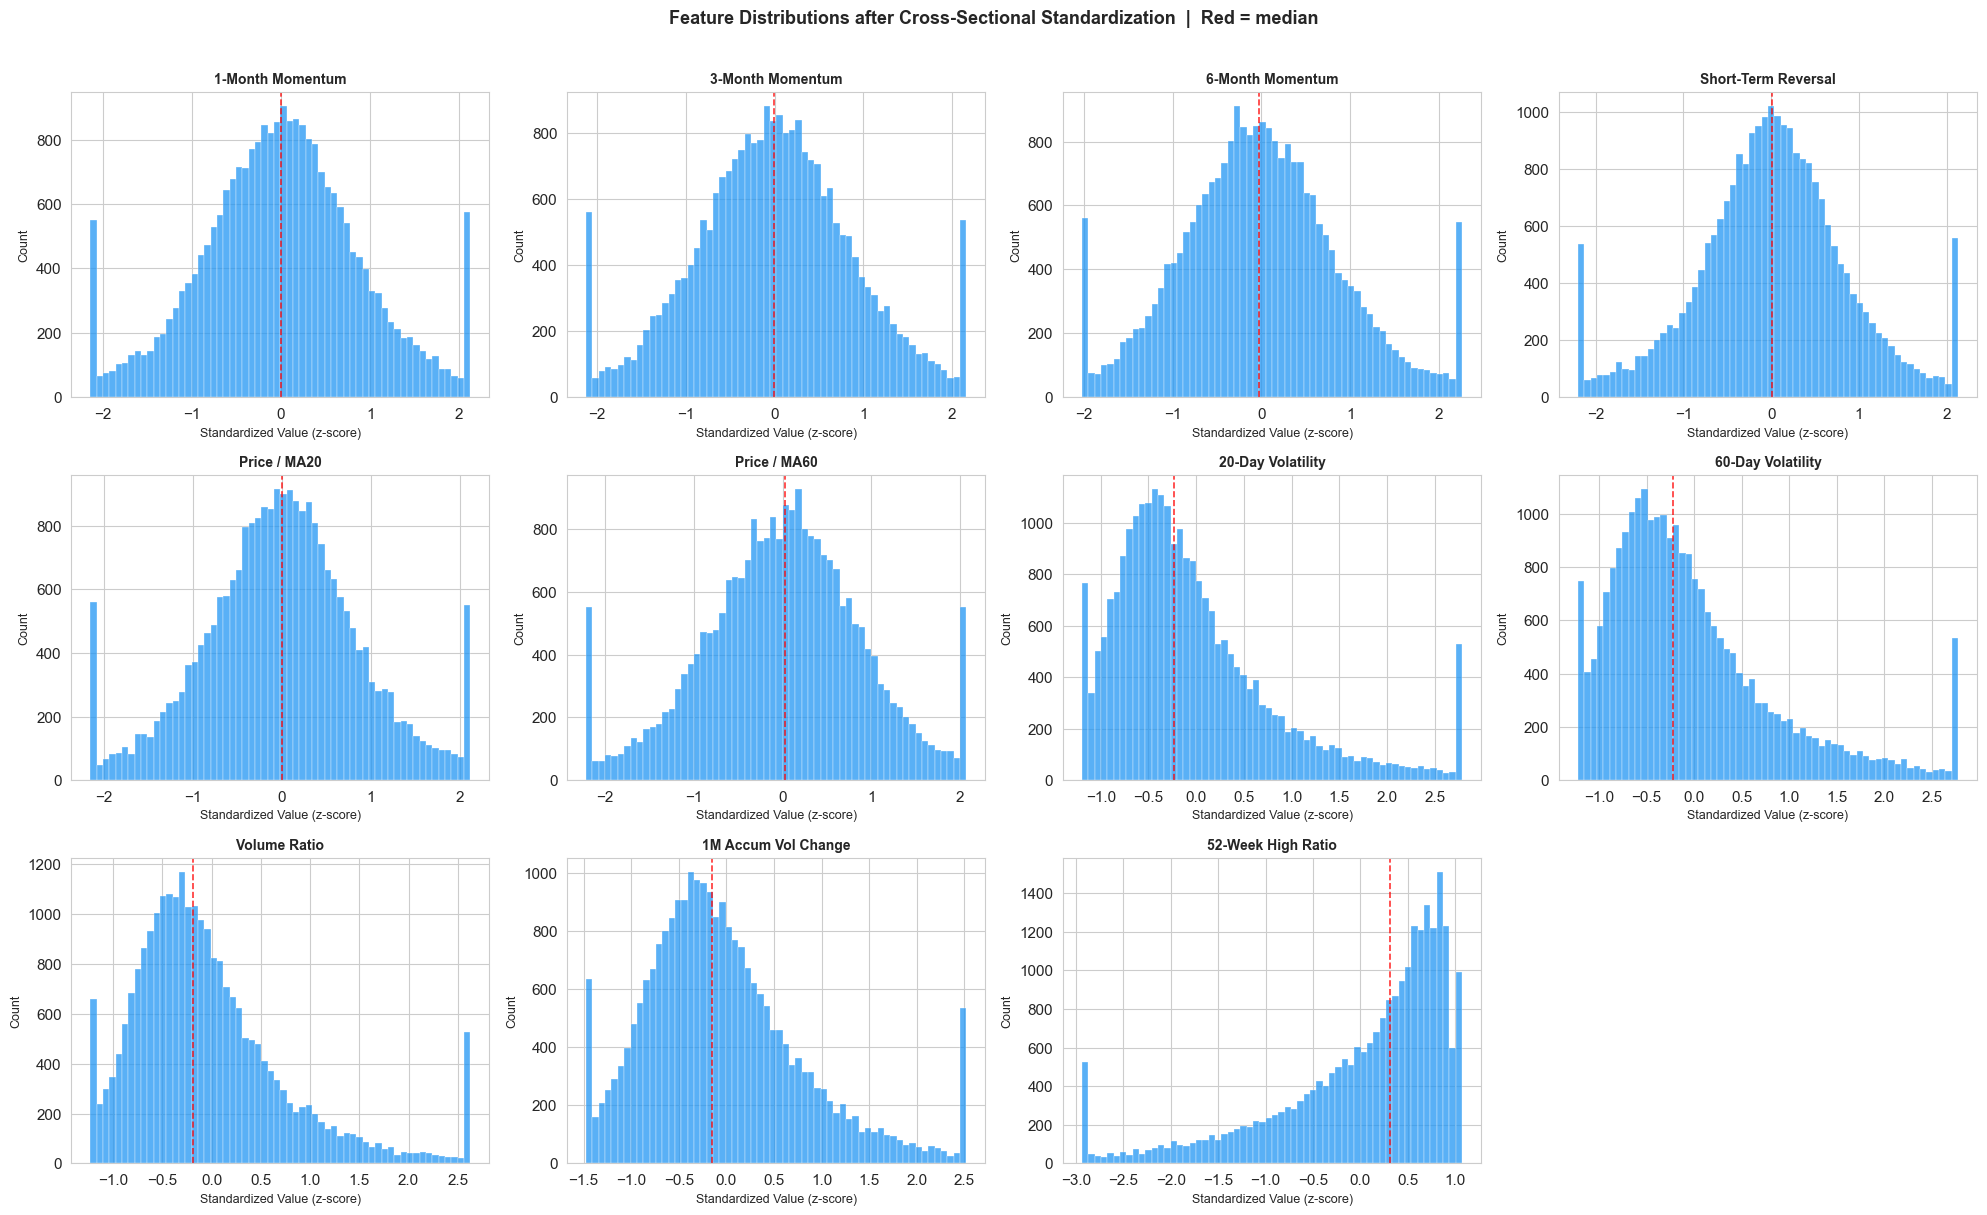

Saved: feature_distributions.png


In [71]:
feature_labels = {
    'Momentum_1M':         '1-Month Momentum',
    'Momentum_3M':         '3-Month Momentum',
    'Momentum_6M':         '6-Month Momentum',
    'Short_Rev':           'Short-Term Reversal',
    'Price_to_MA20':       'Price / MA20',
    'Price_to_MA60':       'Price / MA60',
    'Volatility_20d':      '20-Day Volatility',
    'Volatility_60d':      '60-Day Volatility',
    'Volume_Ratio':        'Volume Ratio',
    '1M_Accum_Vol_Change': '1M Accum Vol Change',
    'High_52W_Ratio':      '52-Week High Ratio',
}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))  # 11 features; last subplot hidden
for ax, (col, label) in zip(axes.flat, feature_labels.items()):
    vals = features_df[col].clip(features_df[col].quantile(0.02),
                                 features_df[col].quantile(0.98))
    ax.hist(vals, bins=60, color='#2196F3', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.median(), color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Standardized Value (z-score)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

# Hide the unused 12th subplot slot
for ax in axes.flat[len(feature_labels):]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions after Cross-Sectional Standardization  |  Red = median',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

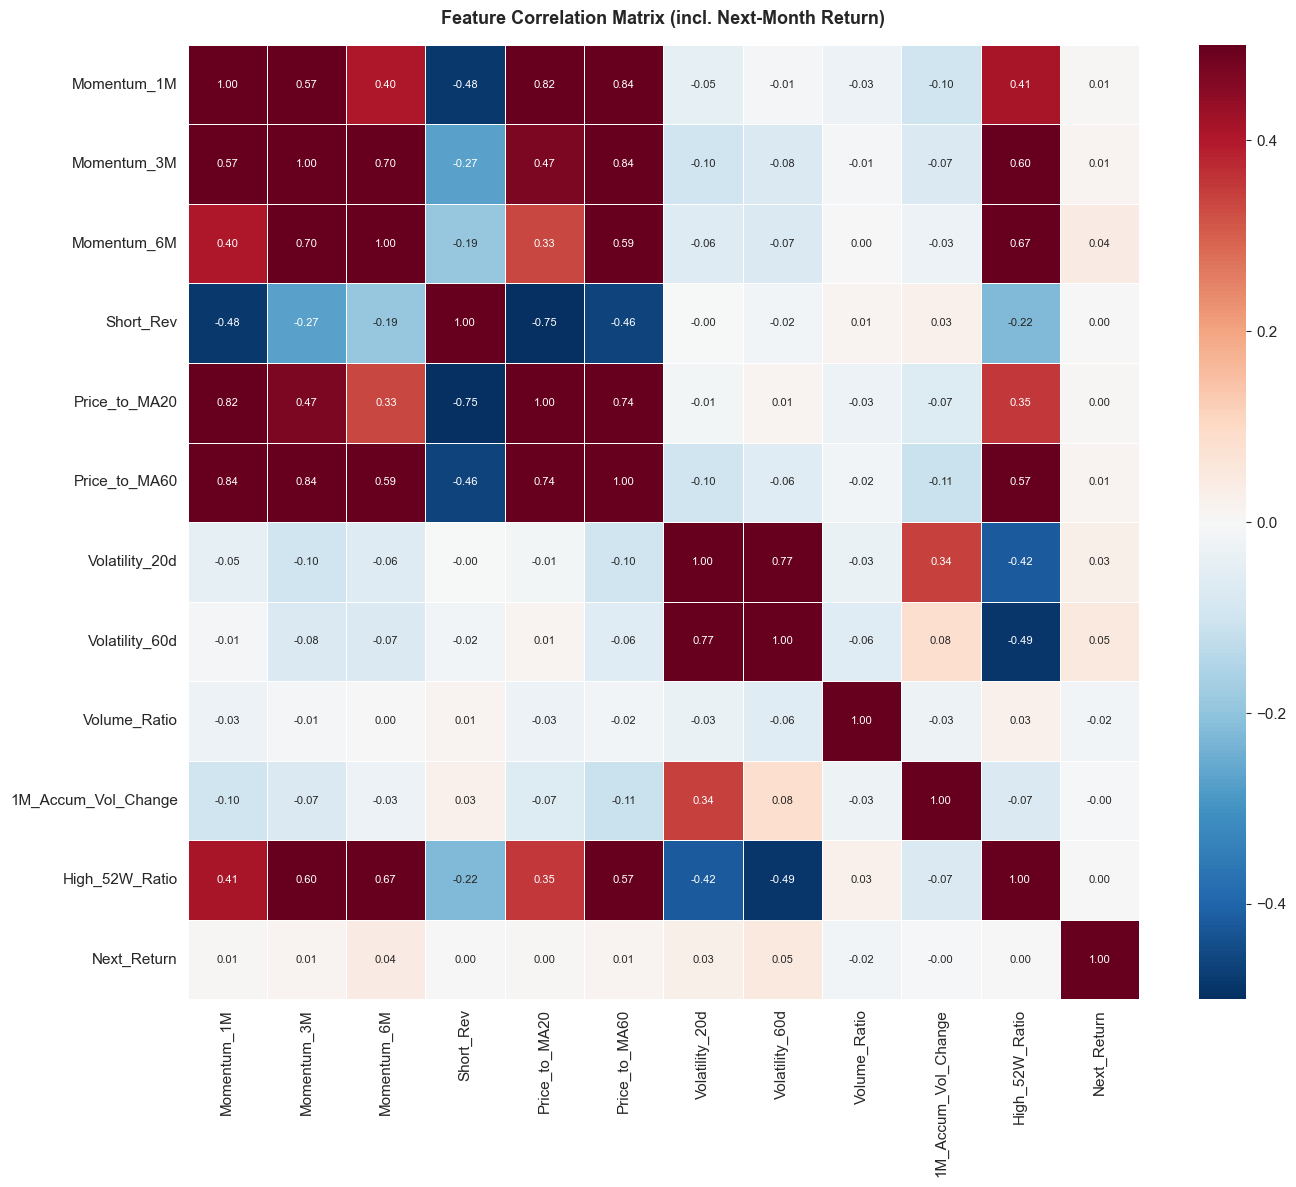

Saved: feature_correlation.png


In [72]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = features_df[FEATURE_COLS + ['Next_Return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-0.5, vmax=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (incl. 3-Month Forward Return)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: feature_correlation.png')

## Step 6: Time-Series Cross-Validation (Expanding Window)

To prevent **look-ahead bias**, we use an expanding-window scheme where the validation year
always comes after all training years.

Each year now contributes ~12 months × ~450 stocks ≈ **5,400 observations**,
giving substantially more training signal than the previous single-month-per-year approach.

| Fold | Training years | Validation year | Approx. train obs |
|------|----------------|-----------------|-------------------|
| 1 | 2013 | 2014 | ~5,400 |
| 2 | 2013–2014 | 2015 | ~10,800 |
| 3 | 2013–2015 | 2016 | ~16,200 |

**Final test:** trained on 2013–2016 (~21,600 obs), evaluated on 2017.

In [73]:
CV_FOLDS = [
    ([2013],             2014),
    ([2013, 2014],       2015),
    ([2013, 2014, 2015], 2016),
]
FINAL_TRAIN_YEARS = [2013, 2014, 2015, 2016]
TEST_YEAR = 2017


def get_split(df, train_years, val_year):
    """Return train/val arrays and the full val DataFrame."""
    tr = df[df['year'].isin(train_years)]
    va = df[df['year'] == val_year]
    return (
        tr[FEATURE_COLS].values,
        tr['Next_Return'].values,
        tr['Binary_Target'].values,
        va[FEATURE_COLS].values,
        va['Next_Return'].values,
        va['Binary_Target'].values,
        va.reset_index(drop=True),
    )


print('Expanding-window CV structure:')
print('-' * 65)
for train_yrs, val_yr in CV_FOLDS:
    n_tr = len(features_df[features_df['year'].isin(train_yrs)])
    n_va = len(features_df[features_df['year'] == val_yr])
    print(f'  Train: {train_yrs}  ({n_tr:,} obs)  ->  Val: {val_yr}  ({n_va:,} obs)')
n_te = len(features_df[features_df['year'] == TEST_YEAR])
print(f'  Final test: {TEST_YEAR}  ({n_te:,} obs)')
print('-' * 65)

Expanding-window CV structure:
-----------------------------------------------------------------
  Train: [2013]  (2,387 obs)  ->  Val: 2014  (5,800 obs)
  Train: [2013, 2014]  (8,187 obs)  ->  Val: 2015  (5,861 obs)
  Train: [2013, 2014, 2015]  (14,048 obs)  ->  Val: 2016  (5,939 obs)
  Final test: 2017  (4,990 obs)
-----------------------------------------------------------------


### 6.1 Logistic Regression — Cross-Validation

We search over the regularisation strength **C** (inverse of L2 penalty).
Smaller C → stronger regularisation; larger C → closer fit to training data.

In [74]:
print('=' * 65)
print('LOGISTIC REGRESSION  --  Hyperparameter Search (C by avg AUC)')
print('=' * 65)

LR_C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0]
lr_c_aucs = {C: [] for C in LR_C_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)
    for C in LR_C_GRID:
        lr = LogisticRegression(C=C, max_iter=2000, random_state=42, solver='lbfgs')
        lr.fit(X_tr_sc, y_tr_c)
        prob = lr.predict_proba(X_va_sc)[:, 1]
        lr_c_aucs[C].append(roc_auc_score(y_va_c, prob))

lr_avg_aucs = {C: np.mean(v) for C, v in lr_c_aucs.items()}
BEST_C_LR = max(lr_avg_aucs, key=lr_avg_aucs.get)

print(f'  {"C":>8} | {"Fold1":>8} | {"Fold2":>8} | {"Fold3":>8} | {"Avg AUC":>8}')
print('  ' + '-' * 52)
for C in LR_C_GRID:
    aucs = lr_c_aucs[C]
    marker = '  <- BEST' if C == BEST_C_LR else ''
    print(f'  {C:>8.3f} | {aucs[0]:>8.4f} | {aucs[1]:>8.4f} | {aucs[2]:>8.4f} | '
          f'{np.mean(aucs):>8.4f}{marker}')
print(f'\nSelected C = {BEST_C_LR}')

LOGISTIC REGRESSION  --  Hyperparameter Search (C by avg AUC)
         C |    Fold1 |    Fold2 |    Fold3 |  Avg AUC
  ----------------------------------------------------
     0.001 |   0.5949 |   0.5261 |   0.6581 |   0.5930  <- BEST
     0.010 |   0.5926 |   0.5233 |   0.6545 |   0.5902
     0.100 |   0.5850 |   0.5215 |   0.6520 |   0.5862
     1.000 |   0.5811 |   0.5212 |   0.6517 |   0.5846
    10.000 |   0.5805 |   0.5211 |   0.6517 |   0.5844

Selected C = 0.001


In [75]:
print(f'\nLogistic Regression CV Results  (C={BEST_C_LR})')
print('-' * 50)

lr_cv_results = []
lr_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)

    lr = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
    lr.fit(X_tr_sc, y_tr_c)
    prob = lr.predict_proba(X_va_sc)[:, 1]
    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(y_va_c, pred)
    auc = roc_auc_score(y_va_c, prob)
    lr_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
    # Store probability scores, actual 3-month forward returns, and ym for month-by-month portfolio
    lr_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score':   prob,
                            'actual':  y_va_r,
                            'ym':      va_df['ym'].values}
    print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

lr_cv_df = pd.DataFrame(lr_cv_results)
print(f'\n  Mean Accuracy : {lr_cv_df.accuracy.mean():.4f} +/- {lr_cv_df.accuracy.std():.4f}')
print(f'  Mean AUC      : {lr_cv_df.auc.mean():.4f} +/- {lr_cv_df.auc.std():.4f}')


Logistic Regression CV Results  (C=0.001)
--------------------------------------------------
  Val 2014:  Accuracy = 0.7988  |  AUC = 0.5949
  Val 2015:  Accuracy = 0.7983  |  AUC = 0.5261
  Val 2016:  Accuracy = 0.7981  |  AUC = 0.6581

  Mean Accuracy : 0.7984 +/- 0.0003
  Mean AUC      : 0.5930 +/- 0.0660


### 6.2 Random Forest — Cross-Validation

In [76]:
print('=' * 65)
print('RANDOM FOREST  --  Hyperparameter Search (avg AUC, Classifier)')
print('=' * 65)

RF_PARAM_GRID = list(product([3, 5, 7], [5, 10]))  # max_depth, min_samples_leaf
rf_param_aucs = {p: [] for p in RF_PARAM_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    for max_d, min_leaf in RF_PARAM_GRID:
        # Use RandomForestClassifier with Binary_Target
        rf = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                                    min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_c)
        prob = rf.predict_proba(X_va)[:, 1]
        rf_param_aucs[(max_d, min_leaf)].append(roc_auc_score(y_va_c, prob))

rf_avg_aucs  = {p: np.mean(v) for p, v in rf_param_aucs.items()}
BEST_PARAMS_RF = max(rf_avg_aucs, key=rf_avg_aucs.get)

print(f'  {"max_depth":>10} | {"min_leaf":>8} | {"Fold1":>10} | {"Fold2":>10} | '
      f'{"Fold3":>10} | {"Avg AUC":>10}')
print('  ' + '-' * 68)
for (max_d, min_leaf) in RF_PARAM_GRID:
    aucs   = rf_param_aucs[(max_d, min_leaf)]
    marker = '  <- BEST' if (max_d, min_leaf) == BEST_PARAMS_RF else ''
    print(f'  {max_d:>10} | {min_leaf:>8} | {aucs[0]:>10.4f} | {aucs[1]:>10.4f} | '
          f'{aucs[2]:>10.4f} | {np.mean(aucs):>10.4f}{marker}')
print(f'\nSelected: max_depth={BEST_PARAMS_RF[0]}, min_samples_leaf={BEST_PARAMS_RF[1]}')

RANDOM FOREST  --  Hyperparameter Search (avg AUC, Classifier)
   max_depth | min_leaf |      Fold1 |      Fold2 |      Fold3 |    Avg AUC
  --------------------------------------------------------------------
           3 |        5 |     0.5911 |     0.5319 |     0.6458 |     0.5896
           3 |       10 |     0.5917 |     0.5316 |     0.6457 |     0.5897  <- BEST
           5 |        5 |     0.5917 |     0.5287 |     0.6449 |     0.5884
           5 |       10 |     0.5909 |     0.5301 |     0.6456 |     0.5889
           7 |        5 |     0.5871 |     0.5241 |     0.6395 |     0.5836
           7 |       10 |     0.5856 |     0.5246 |     0.6407 |     0.5836

Selected: max_depth=3, min_samples_leaf=10


In [77]:
print(f'\nRandom Forest CV Results  (max_depth={BEST_PARAMS_RF[0]}, '
      f'min_leaf={BEST_PARAMS_RF[1]})')
print('-' * 50)

rf_cv_results = []
rf_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    max_d, min_leaf = BEST_PARAMS_RF
    # RandomForestClassifier trained on Binary_Target
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                                min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr_c)
    prob = rf.predict_proba(X_va)[:, 1]   # probability of being in top-20% (training label threshold)
    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(y_va_c, pred)
    auc = roc_auc_score(y_va_c, prob)
    rf_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
    # Store probability scores, actual 3-month forward returns, and ym for month-by-month portfolio
    rf_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score':   prob,
                            'actual':  y_va_r,
                            'ym':      va_df['ym'].values}
    print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

rf_cv_df = pd.DataFrame(rf_cv_results)
print(f'\n  Mean Accuracy : {rf_cv_df.accuracy.mean():.4f} +/- {rf_cv_df.accuracy.std():.4f}')
print(f'  Mean AUC      : {rf_cv_df.auc.mean():.4f} +/- {rf_cv_df.auc.std():.4f}')


Random Forest CV Results  (max_depth=3, min_leaf=10)
--------------------------------------------------
  Val 2014:  Accuracy = 0.7991  |  AUC = 0.5917
  Val 2015:  Accuracy = 0.7994  |  AUC = 0.5316
  Val 2016:  Accuracy = 0.7990  |  AUC = 0.6457

  Mean Accuracy : 0.7991 +/- 0.0002
  Mean AUC      : 0.5897 +/- 0.0571


### 6.3 XGBoost — Cross-Validation

In [78]:
if XGB_AVAILABLE:
    print('=' * 65)
    print('XGBOOST  --  Hyperparameter Search + CV  (XGBClassifier, AUC)')
    print('=' * 65)

    XGB_PARAM_GRID = list(product([3, 5], [0.05, 0.1]))  # max_depth, learning_rate
    xgb_param_aucs = {p: [] for p in XGB_PARAM_GRID}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
            features_df, train_yrs, val_yr)
        for max_d, lr in XGB_PARAM_GRID:
            # XGBClassifier trained on Binary_Target
            model = xgb.XGBClassifier(
                n_estimators=100, max_depth=max_d, learning_rate=lr,
                use_label_encoder=False, eval_metric='logloss', random_state=42)
            model.fit(X_tr, y_tr_c)
            prob = model.predict_proba(X_va)[:, 1]
            xgb_param_aucs[(max_d, lr)].append(roc_auc_score(y_va_c, prob))

    xgb_avg_aucs   = {p: np.mean(v) for p, v in xgb_param_aucs.items()}
    BEST_PARAMS_XGB = max(xgb_avg_aucs, key=xgb_avg_aucs.get)

    print(f'  {"max_depth":>10} | {"lr":>8} | {"Fold1":>10} | {"Fold2":>10} | '
          f'{"Fold3":>10} | {"Avg AUC":>10}')
    print('  ' + '-' * 66)
    for (max_d, lr) in XGB_PARAM_GRID:
        aucs   = xgb_param_aucs[(max_d, lr)]
        marker = '  <- BEST' if (max_d, lr) == BEST_PARAMS_XGB else ''
        print(f'  {max_d:>10} | {lr:>8.2f} | {aucs[0]:>10.4f} | {aucs[1]:>10.4f} | '
              f'{aucs[2]:>10.4f} | {np.mean(aucs):>10.4f}{marker}')
    print(f'\nSelected: max_depth={BEST_PARAMS_XGB[0]}, learning_rate={BEST_PARAMS_XGB[1]}')

    # ── CV results with best params ───────────────────────────────────────────
    print(f'\nXGBoost CV Results  (max_depth={BEST_PARAMS_XGB[0]}, '
          f'lr={BEST_PARAMS_XGB[1]})')
    print('-' * 50)

    xgb_cv_results = []
    xgb_val_preds  = {}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
            features_df, train_yrs, val_yr)
        max_d, lr = BEST_PARAMS_XGB
        model = xgb.XGBClassifier(
            n_estimators=100, max_depth=max_d, learning_rate=lr,
            use_label_encoder=False, eval_metric='logloss', random_state=42)
        model.fit(X_tr, y_tr_c)
        prob = model.predict_proba(X_va)[:, 1]
        pred = (prob >= 0.5).astype(int)

        acc = accuracy_score(y_va_c, pred)
        auc = roc_auc_score(y_va_c, prob)
        xgb_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
        # Store probability scores, actual 3-month forward returns, and ym for month-by-month portfolio
        xgb_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                                  'score':   prob,
                                  'actual':  y_va_r,
                                  'ym':      va_df['ym'].values}
        print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

    xgb_cv_df = pd.DataFrame(xgb_cv_results)
    print(f'\n  Mean Accuracy : {xgb_cv_df.accuracy.mean():.4f} +/- {xgb_cv_df.accuracy.std():.4f}')
    print(f'  Mean AUC      : {xgb_cv_df.auc.mean():.4f} +/- {xgb_cv_df.auc.std():.4f}')

else:
    xgb_val_preds   = {}
    xgb_cv_df       = None
    BEST_PARAMS_XGB = None
    print('XGBoost not available; skipping.')

XGBOOST  --  Hyperparameter Search + CV  (XGBClassifier, AUC)
   max_depth |       lr |      Fold1 |      Fold2 |      Fold3 |    Avg AUC
  ------------------------------------------------------------------
           3 |     0.05 |     0.5872 |     0.5238 |     0.6423 |     0.5844  <- BEST
           3 |     0.10 |     0.5835 |     0.5201 |     0.6320 |     0.5785
           5 |     0.05 |     0.5757 |     0.5217 |     0.6287 |     0.5753
           5 |     0.10 |     0.5688 |     0.5225 |     0.6115 |     0.5676

Selected: max_depth=3, learning_rate=0.05

XGBoost CV Results  (max_depth=3, lr=0.05)
--------------------------------------------------
  Val 2014:  Accuracy = 0.7974  |  AUC = 0.5872
  Val 2015:  Accuracy = 0.7999  |  AUC = 0.5238
  Val 2016:  Accuracy = 0.7988  |  AUC = 0.6423

  Mean Accuracy : 0.7987 +/- 0.0012
  Mean AUC      : 0.5844 +/- 0.0593


### 6.4 Cross-Validation Results Summary

In [79]:
print('=' * 72)
print('CROSS-VALIDATION RESULTS SUMMARY  (Expanding Window — All Classification)')
print('=' * 72)

print(f'\n  {"Model":<22} {"Val Year":>10} {"Accuracy":>12} {"AUC":>12}')
print('  ' + '-' * 58)

# Logistic Regression
for _, row in lr_cv_df.iterrows():
    print(f'  {"Logistic Regression":<22} {int(row.val_year):>10} '
          f'{row.accuracy:>12.4f} {row.auc:>12.4f}')
print(f'  {"  Mean ± Std":<22} {"":>10} '
      f'{lr_cv_df.accuracy.mean():>12.4f}±{lr_cv_df.accuracy.std():.4f} '
      f'{lr_cv_df.auc.mean():>6.4f}±{lr_cv_df.auc.std():.4f}')

print()

# Random Forest
for _, row in rf_cv_df.iterrows():
    print(f'  {"Random Forest":<22} {int(row.val_year):>10} '
          f'{row.accuracy:>12.4f} {row.auc:>12.4f}')
print(f'  {"  Mean ± Std":<22} {"":>10} '
      f'{rf_cv_df.accuracy.mean():>12.4f}±{rf_cv_df.accuracy.std():.4f} '
      f'{rf_cv_df.auc.mean():>6.4f}±{rf_cv_df.auc.std():.4f}')

# XGBoost
if XGB_AVAILABLE and xgb_cv_df is not None:
    print()
    for _, row in xgb_cv_df.iterrows():
        print(f'  {"XGBoost":<22} {int(row.val_year):>10} '
              f'{row.accuracy:>12.4f} {row.auc:>12.4f}')
    print(f'  {"  Mean ± Std":<22} {"":>10} '
          f'{xgb_cv_df.accuracy.mean():>12.4f}±{xgb_cv_df.accuracy.std():.4f} '
          f'{xgb_cv_df.auc.mean():>6.4f}±{xgb_cv_df.auc.std():.4f}')

CROSS-VALIDATION RESULTS SUMMARY  (Expanding Window — All Classification)

  Model                    Val Year     Accuracy          AUC
  ----------------------------------------------------------
  Logistic Regression          2014       0.7988       0.5949
  Logistic Regression          2015       0.7983       0.5261
  Logistic Regression          2016       0.7981       0.6581
    Mean ± Std                            0.7984±0.0003 0.5930±0.0660

  Random Forest                2014       0.7991       0.5917
  Random Forest                2015       0.7994       0.5316
  Random Forest                2016       0.7990       0.6457
    Mean ± Std                            0.7991±0.0002 0.5897±0.0571

  XGBoost                      2014       0.7974       0.5872
  XGBoost                      2015       0.7999       0.5238
  XGBoost                      2016       0.7988       0.6423
    Mean ± Std                            0.7987±0.0012 0.5844±0.0593


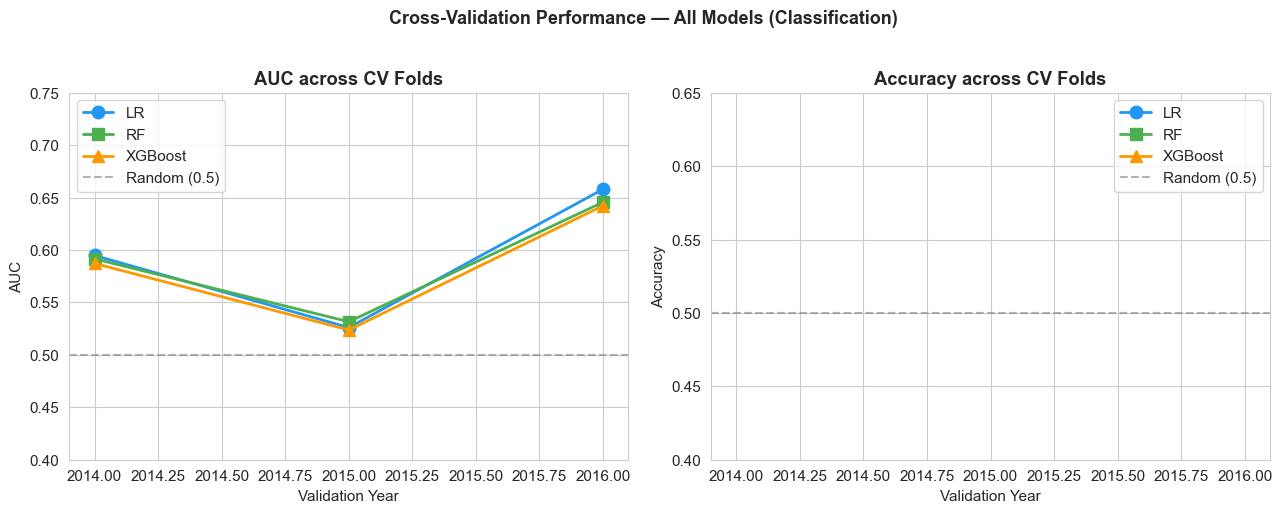

Saved: cv_results.png


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: AUC across folds for all models ────────────────────────────────────
ax = axes[0]
ax.plot(lr_cv_df['val_year'],  lr_cv_df['auc'],  'o-', color='#2196F3',
        label='LR',      linewidth=2, markersize=9)
ax.plot(rf_cv_df['val_year'],  rf_cv_df['auc'],  's-', color='#4CAF50',
        label='RF',      linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['auc'], '^-', color='#FF9800',
            label='XGBoost', linewidth=2, markersize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.set_title('AUC across CV Folds', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 0.75)
ax.legend()

# ── Right: Accuracy across folds for all models ───────────────────────────────
ax = axes[1]
ax.plot(lr_cv_df['val_year'],  lr_cv_df['accuracy'],  'o-', color='#2196F3',
        label='LR',      linewidth=2, markersize=9)
ax.plot(rf_cv_df['val_year'],  rf_cv_df['accuracy'],  's-', color='#4CAF50',
        label='RF',      linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['accuracy'], '^-', color='#FF9800',
            label='XGBoost', linewidth=2, markersize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random (0.5)')
ax.set_title('Accuracy across CV Folds', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 0.65)
ax.legend()

plt.suptitle('Cross-Validation Performance — All Models (Classification)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()
print('Saved: cv_results.png')

## Step 7: Final Out-of-Sample Evaluation (2017)

All three models are retrained on the full 2013–2016 dataset (~21,600 observations)
and evaluated on 2017 (~5,400 observations) — data the models have never seen.

In [81]:
print('=' * 72)
print('FINAL OUT-OF-SAMPLE EVALUATION  --  Test Year 2017  (All Classification)')
print('=' * 72)

# ── Prepare train (2013–2016) and test (2017) splits ─────────────────────────
X_tr_f   = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)][FEATURE_COLS].values
y_tr_f_r = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)]['Next_Return'].values
y_tr_f_c = features_df[features_df['year'].isin(FINAL_TRAIN_YEARS)]['Binary_Target'].values

te_df  = features_df[features_df['year'] == TEST_YEAR].reset_index(drop=True)
X_te   = te_df[FEATURE_COLS].values
y_te_r = te_df['Next_Return'].values
y_te_c = te_df['Binary_Target'].values

print(f'\nTrain: {FINAL_TRAIN_YEARS}  ({len(X_tr_f):,} obs)  ->  Test: {TEST_YEAR}  ({len(X_te):,} obs)')

# ── Logistic Regression ───────────────────────────────────────────────────────
scaler_f  = StandardScaler()
X_tr_f_sc = scaler_f.fit_transform(X_tr_f)
X_te_sc   = scaler_f.transform(X_te)

lr_f     = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
lr_f.fit(X_tr_f_sc, y_tr_f_c)
lr_prob_te = lr_f.predict_proba(X_te_sc)[:, 1]
lr_pred_te = (lr_prob_te >= 0.5).astype(int)
lr_acc_te  = accuracy_score(y_te_c, lr_pred_te)
lr_auc_te  = roc_auc_score(y_te_c, lr_prob_te)
lr_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                            'score':   lr_prob_te,
                            'actual':  y_te_r,
                            'ym':      te_df['ym'].values}
print(f'\nLogistic Regression  (test {TEST_YEAR}):  Accuracy = {lr_acc_te:.4f}  |  AUC = {lr_auc_te:.4f}')

# ── Random Forest ─────────────────────────────────────────────────────────────
max_d, min_leaf = BEST_PARAMS_RF
rf_f = RandomForestClassifier(n_estimators=100, max_depth=max_d,
                               min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
rf_f.fit(X_tr_f, y_tr_f_c)
rf_prob_te = rf_f.predict_proba(X_te)[:, 1]
rf_pred_te = (rf_prob_te >= 0.5).astype(int)
rf_acc_te  = accuracy_score(y_te_c, rf_pred_te)
rf_auc_te  = roc_auc_score(y_te_c, rf_prob_te)
rf_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                            'score':   rf_prob_te,
                            'actual':  y_te_r,
                            'ym':      te_df['ym'].values}
print(f'Random Forest        (test {TEST_YEAR}):  Accuracy = {rf_acc_te:.4f}  |  AUC = {rf_auc_te:.4f}')

# ── XGBoost ───────────────────────────────────────────────────────────────────
if XGB_AVAILABLE:
    max_d, lr = BEST_PARAMS_XGB
    xgb_f = xgb.XGBClassifier(
        n_estimators=100, max_depth=max_d, learning_rate=lr,
        use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_f.fit(X_tr_f, y_tr_f_c)
    xgb_prob_te = xgb_f.predict_proba(X_te)[:, 1]
    xgb_pred_te = (xgb_prob_te >= 0.5).astype(int)
    xgb_acc_te  = accuracy_score(y_te_c, xgb_pred_te)
    xgb_auc_te  = roc_auc_score(y_te_c, xgb_prob_te)
    xgb_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                                 'score':   xgb_prob_te,
                                 'actual':  y_te_r,
                                 'ym':      te_df['ym'].values}
    print(f'XGBoost              (test {TEST_YEAR}):  Accuracy = {xgb_acc_te:.4f}  |  AUC = {xgb_auc_te:.4f}')

# Save final-model objects for feature importance (Step 10)
lr_final  = lr_f
rf_final  = rf_f
xgb_final = xgb_f if XGB_AVAILABLE else None

FINAL OUT-OF-SAMPLE EVALUATION  --  Test Year 2017  (All Classification)

Train: [2013, 2014, 2015, 2016]  (19,987 obs)  ->  Test: 2017  (4,990 obs)

Logistic Regression  (test 2017):  Accuracy = 0.7984  |  AUC = 0.5698
Random Forest        (test 2017):  Accuracy = 0.7994  |  AUC = 0.5651
XGBoost              (test 2017):  Accuracy = 0.8002  |  AUC = 0.5652


## Step 8: Ensemble Model

We combine the three models by **rank-averaging** their prediction scores:

1. For each model and for **each calendar month** independently, convert raw prediction
   scores to percentile ranks within that month's cross-section.
2. Average the per-month rank vectors to form the ensemble score for that month.
3. Concatenate monthly results back into the full year array.

Ranking within each month (not across the whole year) keeps the signal cross-sectionally
neutral: a stock is ranked relative to its peers in the same formation month only,
exactly mirroring how the long-only and long-short portfolios are constructed.

In [82]:
def build_ensemble_preds(lr_p, rf_p, xgb_p, years):
    """
    Rank-average LR + RF + XGBoost scores cross-sectionally WITHIN EACH MONTH.

    For every formation month (ym) inside a given evaluation year:
      1. Slice the raw prediction scores for that month from each model.
      2. Convert each model's slice to percentile ranks (0..1) within that
         month's cross-section only — NOT across the full year.
      3. Average the per-model ranks to produce the ensemble score for that month.
    Results are written back into a pre-allocated array and concatenated at the end.

    Why within-month?  Portfolio construction ranks stocks within each month;
    the ensemble signal should be on the same cross-sectional basis to avoid
    spurious rank inflation/deflation caused by month-to-month return dispersion.
    """
    ensemble = {}
    for yr in years:
        sources = [lr_p, rf_p]
        if XGB_AVAILABLE and yr in xgb_p:
            sources.append(xgb_p)

        yms       = lr_p[yr]['ym']
        n         = len(yms)
        avg_score = np.zeros(n, dtype=float)

        for ym_val in np.unique(yms):
            mask = (yms == ym_val)                        # indices for this month
            n_m  = mask.sum()
            # Rank each model's scores within this month only, then average
            monthly_ranks = np.column_stack([
                rankdata(s[yr]['score'][mask]) / n_m      # percentile rank in [1/n, 1]
                for s in sources
            ])
            avg_score[mask] = monthly_ranks.mean(axis=1)

        ensemble[yr] = {
            'tickers': lr_p[yr]['tickers'],
            'score':   avg_score,
            'actual':  lr_p[yr]['actual'],
            'ym':      yms,               # month labels carried forward
        }
    return ensemble


ALL_EVAL_YEARS     = [2014, 2015, 2016, 2017]
ensemble_val_preds = build_ensemble_preds(
    lr_val_preds, rf_val_preds, xgb_val_preds, ALL_EVAL_YEARS)

print('Ensemble predictions ready for years:', list(ensemble_val_preds.keys()))
n_sources = 3 if XGB_AVAILABLE else 2
print(f'Combining {n_sources} models: LR + RF' + (' + XGBoost' if XGB_AVAILABLE else ''))

Ensemble predictions ready for years: [2014, 2015, 2016, 2017]
Combining 3 models: LR + RF + XGBoost


## Step 9: Portfolio Construction & Evaluation

For each year and model we:
1. Rank all stocks by the model's predicted score (descending).
2. Select the **top 10%** as the long portfolio (equal-weighted).
3. Compare its average 3-month forward return against the equal-weighted benchmark (all stocks).

In [83]:
PORTFOLIO_TOPK = 0.10  # top 10% — updated from 20% to match long-short cutoff


def compute_portfolio_return(preds_dict, year, topk=PORTFOLIO_TOPK):
    """
    Month-by-month portfolio construction for a given evaluation year.

    For each formation month (ym) within the year:
      1. Rank stocks by model score WITHIN that month only.
      2. Select the top-topk fraction of stocks for that month.
      3. Compute their equal-weighted average actual 3-month forward return.
      4. Record the equal-weighted benchmark (all stocks that month).

    Final portfolio return = simple average across all months in the year.

    This ensures no cross-month mixing: stocks from different months are
    always ranked and selected independently, which is the correct approach
    for cross-sectional stock selection.
    """
    preds   = preds_dict[year]
    scores  = preds['score']
    actuals = preds['actual']
    yms     = preds['ym']

    monthly_port  = []
    monthly_bench = []

    for ym_val in np.unique(yms):
        mask    = (yms == ym_val)
        ym_sc   = scores[mask]
        ym_act  = actuals[mask]
        n_port  = max(1, int(len(ym_sc) * topk))
        top_idx = np.argsort(ym_sc)[::-1][:n_port]
        monthly_port.append(float(np.mean(ym_act[top_idx])))
        monthly_bench.append(float(np.mean(ym_act)))

    port_ret  = float(np.mean(monthly_port))
    bench_ret = float(np.mean(monthly_bench))
    n_months  = len(monthly_port)
    return port_ret, bench_ret, port_ret - bench_ret, n_months


models_portfolio = [
    ('Logistic Regression', lr_val_preds),
    ('Random Forest',       rf_val_preds),
]
if XGB_AVAILABLE:
    models_portfolio.append(('XGBoost', xgb_val_preds))
models_portfolio.append(('Ensemble', ensemble_val_preds))

portfolio_results = {}

print('=' * 72)
print(f'PORTFOLIO EVALUATION  --  Top {int(PORTFOLIO_TOPK*100)}% Long  (month-by-month construction)')
print('=' * 72)

for model_name, preds_dict in models_portfolio:
    print(f'\n{model_name}:')
    print(f'  {"Year":<8} {"Portfolio":>14} {"Benchmark":>12} {"Excess":>12} {"N months":>10}')
    print('  ' + '-' * 60)
    results = []
    for year in ALL_EVAL_YEARS:
        if year not in preds_dict:
            continue
        p, b, e, n = compute_portfolio_return(preds_dict, year)
        results.append({'year': year, 'portfolio': p, 'benchmark': b, 'excess': e, 'n': n})
        print(f'  {year:<8} {p:>14.4%} {b:>12.4%} {e:>12.4%} {n:>10}')
    rdf = pd.DataFrame(results)
    portfolio_results[model_name] = rdf
    print(f'  {"Mean":<8} {rdf.portfolio.mean():>14.4%} {rdf.benchmark.mean():>12.4%} '
          f'{rdf.excess.mean():>12.4%}')

PORTFOLIO EVALUATION  --  Top 10% Long  (month-by-month construction)

Logistic Regression:
  Year          Portfolio    Benchmark       Excess   N months
  ------------------------------------------------------------
  2014            5.3274%      3.5425%      1.7849%         12
  2015           -4.6542%     -1.2035%     -3.4507%         12
  2016           11.8717%      5.0838%      6.7879%         12
  2017            2.8590%      3.9982%     -1.1393%         10
  Mean            3.8510%      2.8553%      0.9957%

Random Forest:
  Year          Portfolio    Benchmark       Excess   N months
  ------------------------------------------------------------
  2014            4.7689%      3.5425%      1.2264%         12
  2015           -4.0897%     -1.2035%     -2.8862%         12
  2016           11.7562%      5.0838%      6.6724%         12
  2017            3.1130%      3.9982%     -0.8852%         10
  Mean            3.8871%      2.8553%      1.0318%

XGBoost:
  Year          Portfo

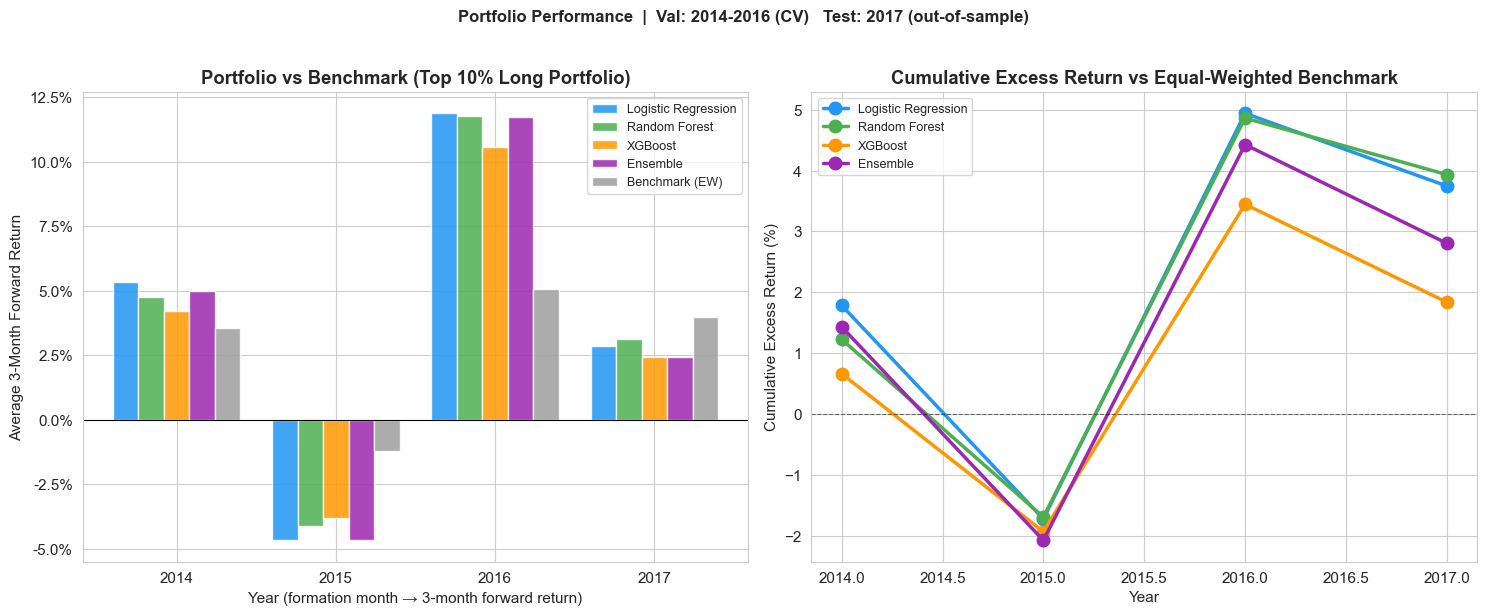

Saved: portfolio_performance.png


In [84]:
n_models   = len(models_portfolio)
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B']
bench_color = '#9E9E9E'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar chart: portfolio return vs benchmark by year ---
ax = axes[0]
x     = np.arange(len(ALL_EVAL_YEARS))
width = 0.8 / (n_models + 1)

for i, (model_name, preds_dict) in enumerate(models_portfolio):
    rdf = portfolio_results[model_name]
    port_rets = [rdf.loc[rdf['year'] == y, 'portfolio'].values[0]
                 if y in rdf['year'].values else np.nan for y in ALL_EVAL_YEARS]
    ax.bar(x + i * width, port_rets, width, label=model_name,
           color=bar_colors[i], alpha=0.85)

# Benchmark
rdf0      = portfolio_results['Logistic Regression']
bench_rets = [rdf0.loc[rdf0['year'] == y, 'benchmark'].values[0]
              if y in rdf0['year'].values else np.nan for y in ALL_EVAL_YEARS]
ax.bar(x + n_models * width, bench_rets, width, label='Benchmark (EW)',
       color=bench_color, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + (n_models / 2) * width)
ax.set_xticklabels(ALL_EVAL_YEARS)
ax.set_xlabel('Year (formation month → 3-month forward return)')
ax.set_ylabel('Average 3-Month Forward Return')
ax.set_title(f'Portfolio vs Benchmark (Top {int(PORTFOLIO_TOPK*100)}% Long Portfolio)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
ax.legend(fontsize=9)

# --- Cumulative excess return ---
ax = axes[1]
for (model_name, _), color in zip(models_portfolio, bar_colors):
    rdf     = portfolio_results[model_name]
    cum_exc = (1 + rdf['excess']).cumprod() - 1
    ax.plot(rdf['year'], cum_exc * 100, 'o-', label=model_name,
            color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.set_title('Cumulative Excess Return vs Equal-Weighted Benchmark', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Portfolio Performance  |  Val: 2014-2016 (CV)   Test: 2017 (out-of-sample)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('portfolio_performance.png', bbox_inches='tight')
plt.show()
print('Saved: portfolio_performance.png')

LONG-SHORT PORTFOLIO  --  Top/Bottom 10%  (month-by-month)

  Logistic Regression
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.8941%    8.7388%     0.4456
    Long-Short                1.0480%    8.1224%     0.1290

  Random Forest
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.9208%    8.3113%     0.4717
    Long-Short                0.8690%    7.9565%     0.1092

  XGBoost
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.3987%    8.0849%     0.4204
    Long-Short                0.2433%    7.7106%     0.0316

  Ensemble
    Strategy                 Mean Ret    Std Dev     Sharpe
    ------------------------------------------------------
    Long-Only (top 10%)       3.6720%    8

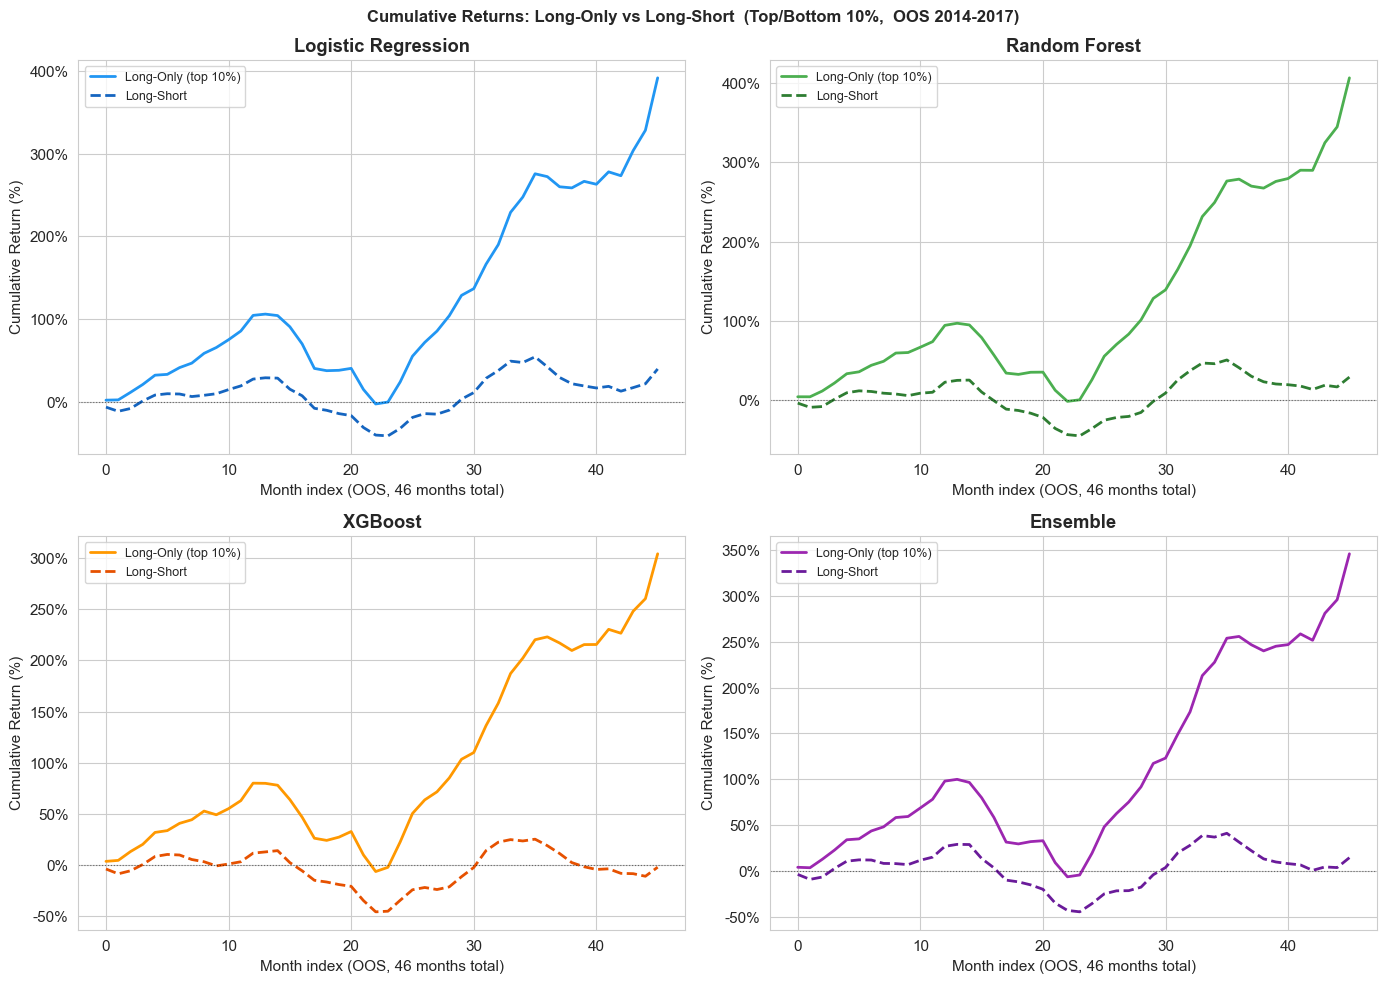

Saved: long_short_performance.png


In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# Long-Short Portfolio Construction & Evaluation
#
# For each month we use ym_pred (model scores) to rank stocks, then:
#   - Long leg  : top 10% by ym_pred → equal-weighted mean of ym_act
#   - Short leg : bottom 10% by ym_pred → equal-weighted mean of ym_act
#   - long_short_return = long_return − short_return
#
# The long-only series (top 10%) is kept for side-by-side comparison.
# ─────────────────────────────────────────────────────────────────────────────

LONG_SHORT_TOPK = 0.10  # top / bottom 10% for long-short legs


def compute_long_short_monthly(preds_dict, years, topk=LONG_SHORT_TOPK):
    """
    Build month-level long-only and long-short returns across multiple years.

    For each month (ym) in the given years:
      - Uses ym_pred (model score) to rank stocks cross-sectionally.
      - long_return  = mean(ym_act) for top-topk% stocks      [long leg]
      - short_return = mean(ym_act) for bottom-topk% stocks   [short leg]
      - long_short_return = long_return − short_return

    Stocks are ranked WITHIN each month only (no cross-month mixing).

    Parameters
    ----------
    preds_dict : dict  {year: {'score': ..., 'actual': ..., 'ym': ...}}
    years      : list of int
    topk       : float — fraction for each leg (default 0.10)

    Returns
    -------
    long_only_rets  : list[float] — monthly long-only returns
    long_short_rets : list[float] — monthly long-short returns
    ym_labels       : list        — month labels (for reference)
    """
    long_only_rets  = []
    long_short_rets = []
    ym_labels       = []

    for year in years:
        if year not in preds_dict:
            continue
        preds   = preds_dict[year]
        scores  = preds['score']    # ym_pred: model probability scores
        actuals = preds['actual']   # ym_act:  realised 3-month forward returns
        yms     = preds['ym']

        for ym_val in np.unique(yms):
            mask   = (yms == ym_val)
            ym_sc  = scores[mask]   # ym_pred for this month
            ym_act = actuals[mask]  # ym_act  for this month

            n_select   = max(1, int(len(ym_sc) * topk))
            sorted_idx = np.argsort(ym_sc)[::-1]          # descending by score
            top_idx    = sorted_idx[:n_select]             # top 10%  → long
            bottom_idx = sorted_idx[-n_select:]            # bottom 10% → short

            long_ret  = float(np.mean(ym_act[top_idx]))
            short_ret = float(np.mean(ym_act[bottom_idx]))

            # long_only_return: equal-weighted mean of top 10%
            long_only_rets.append(long_ret)
            # long_short_return = long_return − short_return
            long_short_rets.append(long_ret - short_ret)
            ym_labels.append(ym_val)

    return long_only_rets, long_short_rets, ym_labels


# ── Run for all models, collect results ──────────────────────────────────────
print('=' * 72)
print(f'LONG-SHORT PORTFOLIO  --  Top/Bottom {int(LONG_SHORT_TOPK*100)}%  (month-by-month)')
print('=' * 72)

# ls_results stores monthly return arrays for each model
ls_results = {}

for model_name, preds_dict in models_portfolio:
    lo_rets, ls_rets, ym_labs = compute_long_short_monthly(
        preds_dict, ALL_EVAL_YEARS, topk=LONG_SHORT_TOPK)

    # Store both series for later plotting
    ls_results[model_name] = {
        'long_only':  np.array(lo_rets),    # long_only_return per month
        'long_short': np.array(ls_rets),    # long_short_return per month
        'ym':         ym_labs,
    }

    # ── Summary statistics (mean, std, Sharpe; risk-free rate = 0) ───────────
    lo_mean   = float(np.mean(lo_rets))
    lo_std    = float(np.std(lo_rets, ddof=1))
    lo_sharpe = lo_mean / lo_std if lo_std > 0 else np.nan

    ls_mean   = float(np.mean(ls_rets))
    ls_std    = float(np.std(ls_rets, ddof=1))
    ls_sharpe = ls_mean / ls_std if ls_std > 0 else np.nan

    print(f'\n  {model_name}')
    print(f'    {"Strategy":<22} {"Mean Ret":>10} {"Std Dev":>10} {"Sharpe":>10}')
    print(f'    {"-"*54}')
    print(f'    {"Long-Only (top 10%)":<22} {lo_mean:>10.4%} {lo_std:>10.4%} {lo_sharpe:>10.4f}')
    print(f'    {"Long-Short":<22} {ls_mean:>10.4%} {ls_std:>10.4%} {ls_sharpe:>10.4f}')


# ── Plot: cumulative returns long-only vs long-short, one subplot per model ───
# Each month contributes one data point; cumulative product chains them.
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B']
ls_colors  = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#37474F']  # darker shades

n_m  = len(models_portfolio)
ncols = min(n_m, 2)
nrows = (n_m + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for idx, (model_name, _) in enumerate(models_portfolio):
    ax      = axes_flat[idx]
    res     = ls_results[model_name]
    lo      = res['long_only']
    ls      = res['long_short']
    x       = np.arange(len(lo))
    cum_lo  = (1 + lo).cumprod() - 1   # cumulative long-only return
    cum_ls  = (1 + ls).cumprod() - 1   # cumulative long-short return

    ax.plot(x, cum_lo * 100, label=f'Long-Only (top {int(LONG_SHORT_TOPK*100)}%)',
            color=bar_colors[idx], linewidth=2)
    ax.plot(x, cum_ls * 100, label='Long-Short',
            color=ls_colors[idx], linewidth=2, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel(f'Month index (OOS, {len(lo)} months total)')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# Hide unused subplots if n_m is odd
for j in range(n_m, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    f'Cumulative Returns: Long-Only vs Long-Short  '
    f'(Top/Bottom {int(LONG_SHORT_TOPK*100)}%,  OOS 2014-2017)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('long_short_performance.png', bbox_inches='tight')
plt.show()
print('Saved: long_short_performance.png')


In [86]:
# ─────────────────────────────────────────────────────────────────────────
# Benchmark 2: Random Selection
#
# A random baseline randomly selects the top `frac` fraction of stocks each
# month without using any model signal.  It represents naive stock-picking
# and helps evaluate whether the model adds real value over random chance.
# ─────────────────────────────────────────────────────────────────────────

def compute_random_portfolio_return(df, frac=0.1, n_sim=50):
    """
    Random selection baseline (Benchmark 2).

    For each month (grouped by 'ym'):
      - Repeat n_sim times: randomly select int(N * frac) stocks (without
        replacement) and record their equal-weighted mean Next_Return.
      - The month's return is the average across all simulations.

    Random selection is always done WITHIN each month — stocks are never
    mixed across months.

    Returns
    -------
    overall_return : float
        Mean portfolio return averaged across all months.
    overall_std : float
        Average within-month simulation standard deviation, showing how
        variable random picks are inside a single month.
    """
    monthly_means = []
    monthly_stds  = []

    for _ym, grp in df.groupby('ym'):
        returns  = grp['Next_Return'].values
        n_select = max(1, int(len(returns) * frac))

        # n_sim independent random draws within this month
        sim_returns = [
            np.mean(np.random.choice(returns, size=n_select, replace=False))
            for _ in range(n_sim)
        ]

        monthly_means.append(np.mean(sim_returns))
        monthly_stds.append(np.std(sim_returns))

    overall_return = float(np.mean(monthly_means))
    overall_std    = float(np.mean(monthly_stds))  # avg within-month variability
    return overall_return, overall_std


# ── Run the random benchmark on out-of-sample data only ──────────────────────
oos_df = features_df[features_df['year'].isin(ALL_EVAL_YEARS)].copy()

np.random.seed(42)  # fix seed for reproducibility
random_ret, random_std = compute_random_portfolio_return(
    oos_df, frac=PORTFOLIO_TOPK, n_sim=50
)

# ── Print comparison table ────────────────────────────────────────────────────
print('=' * 62)
print(f'BENCHMARK COMPARISON  --  Top {int(PORTFOLIO_TOPK*100)}% Long  (OOS: 2014–2017)')
print('=' * 62)
print(f'  {"Model / Benchmark":<28} {"Mean Return":>12}')
print('  ' + '-' * 42)
for model_name, rdf in portfolio_results.items():
    model_mean = rdf['portfolio'].mean()   # mean across OOS years
    print(f'  {model_name:<28} {model_mean:>12.4%}')
print('  ' + '-' * 42)
print(f'  {"Random Selection (Benchmark 2)":<28} {random_ret:>12.4%}  '
      f'± {random_std:.4%} (avg monthly sim std)')
print('=' * 62)
print()
print('Note: Random baseline averages 50 independent simulations per month.')
print('      The ± figure reflects within-month variability of random picks,')
print('      not noise across months.')


BENCHMARK COMPARISON  --  Top 10% Long  (OOS: 2014–2017)
  Model / Benchmark             Mean Return
  ------------------------------------------
  Logistic Regression               3.8510%
  Random Forest                     3.8871%
  XGBoost                           3.3589%
  Ensemble                          3.6209%
  ------------------------------------------
  Random Selection (Benchmark 2)      2.8516%  ± 1.4286% (avg monthly sim std)

Note: Random baseline averages 50 independent simulations per month.
      The ± figure reflects within-month variability of random picks,
      not noise across months.


In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# Cross-Sectional Ranking Evaluation
#
# In addition to portfolio returns, we measure *ranking quality*:
#   - IC (Information Coefficient): Spearman correlation between model scores
#     and actual returns within each month. Positive IC means the model ranks
#     higher-returning stocks above lower-returning ones.
#   - Decile analysis: stocks sorted by model score into 10 equal bins;
#     average actual return per bin shows whether the score is monotonically
#     related to real returns.
#   - Long-short return: top decile minus bottom decile — a cleaner signal
#     of the model's discriminative power at both extremes.
# ─────────────────────────────────────────────────────────────────────────────

def compute_ic_and_deciles(preds_dict, year, n_deciles=10):
    """
    Compute monthly IC and average decile returns for one evaluation year.

    For each month (grouped by 'ym'):
      - IC: Spearman rank correlation between model score and actual Next_Return.
        A positive IC means higher model scores tend to coincide with
        higher actual returns — the model ranks stocks correctly.
      - Decile returns: sort stocks by score (ascending), split into n_deciles
        equal groups, record mean actual return per group.
        D1 = lowest predicted score, D10 = highest predicted score.

    Returns
    -------
    monthly_ics : list of (ym, ic) tuples  — one entry per month
    avg_decile_rets : np.ndarray of shape (n_deciles,) — averaged across months
    """
    preds   = preds_dict[year]
    scores  = preds['score']
    actuals = preds['actual']
    yms     = preds['ym']

    monthly_ics         = []
    monthly_decile_rets = []

    for ym_val in np.unique(yms):
        mask   = (yms == ym_val)
        ym_sc  = scores[mask]
        ym_act = actuals[mask]

        # IC: Spearman correlation within this month
        ic, _ = stats.spearmanr(ym_sc, ym_act)
        monthly_ics.append((ym_val, float(ic)))

        # Decile returns: argsort ascending → D1 = lowest score, D10 = highest
        sorted_idx = np.argsort(ym_sc)
        n = len(sorted_idx)
        decile_ret = []
        for d in range(n_deciles):
            start = int(round(d * n / n_deciles))
            end   = int(round((d + 1) * n / n_deciles))
            decile_ret.append(float(np.mean(ym_act[sorted_idx[start:end]])))
        monthly_decile_rets.append(decile_ret)

    avg_decile_rets = np.mean(monthly_decile_rets, axis=0)
    return monthly_ics, avg_decile_rets


CROSS-SECTIONAL RANKING EVALUATION  (IC + Decile Analysis)
  Logistic Regression        Mean IC = -0.0105   Long-Short (D10-D1) = +0.9968%
  Random Forest              Mean IC = -0.0169   Long-Short (D10-D1) = +0.8247%
  XGBoost                    Mean IC = -0.0155   Long-Short (D10-D1) = +0.1036%
  Ensemble                   Mean IC = -0.0148   Long-Short (D10-D1) = +0.4901%


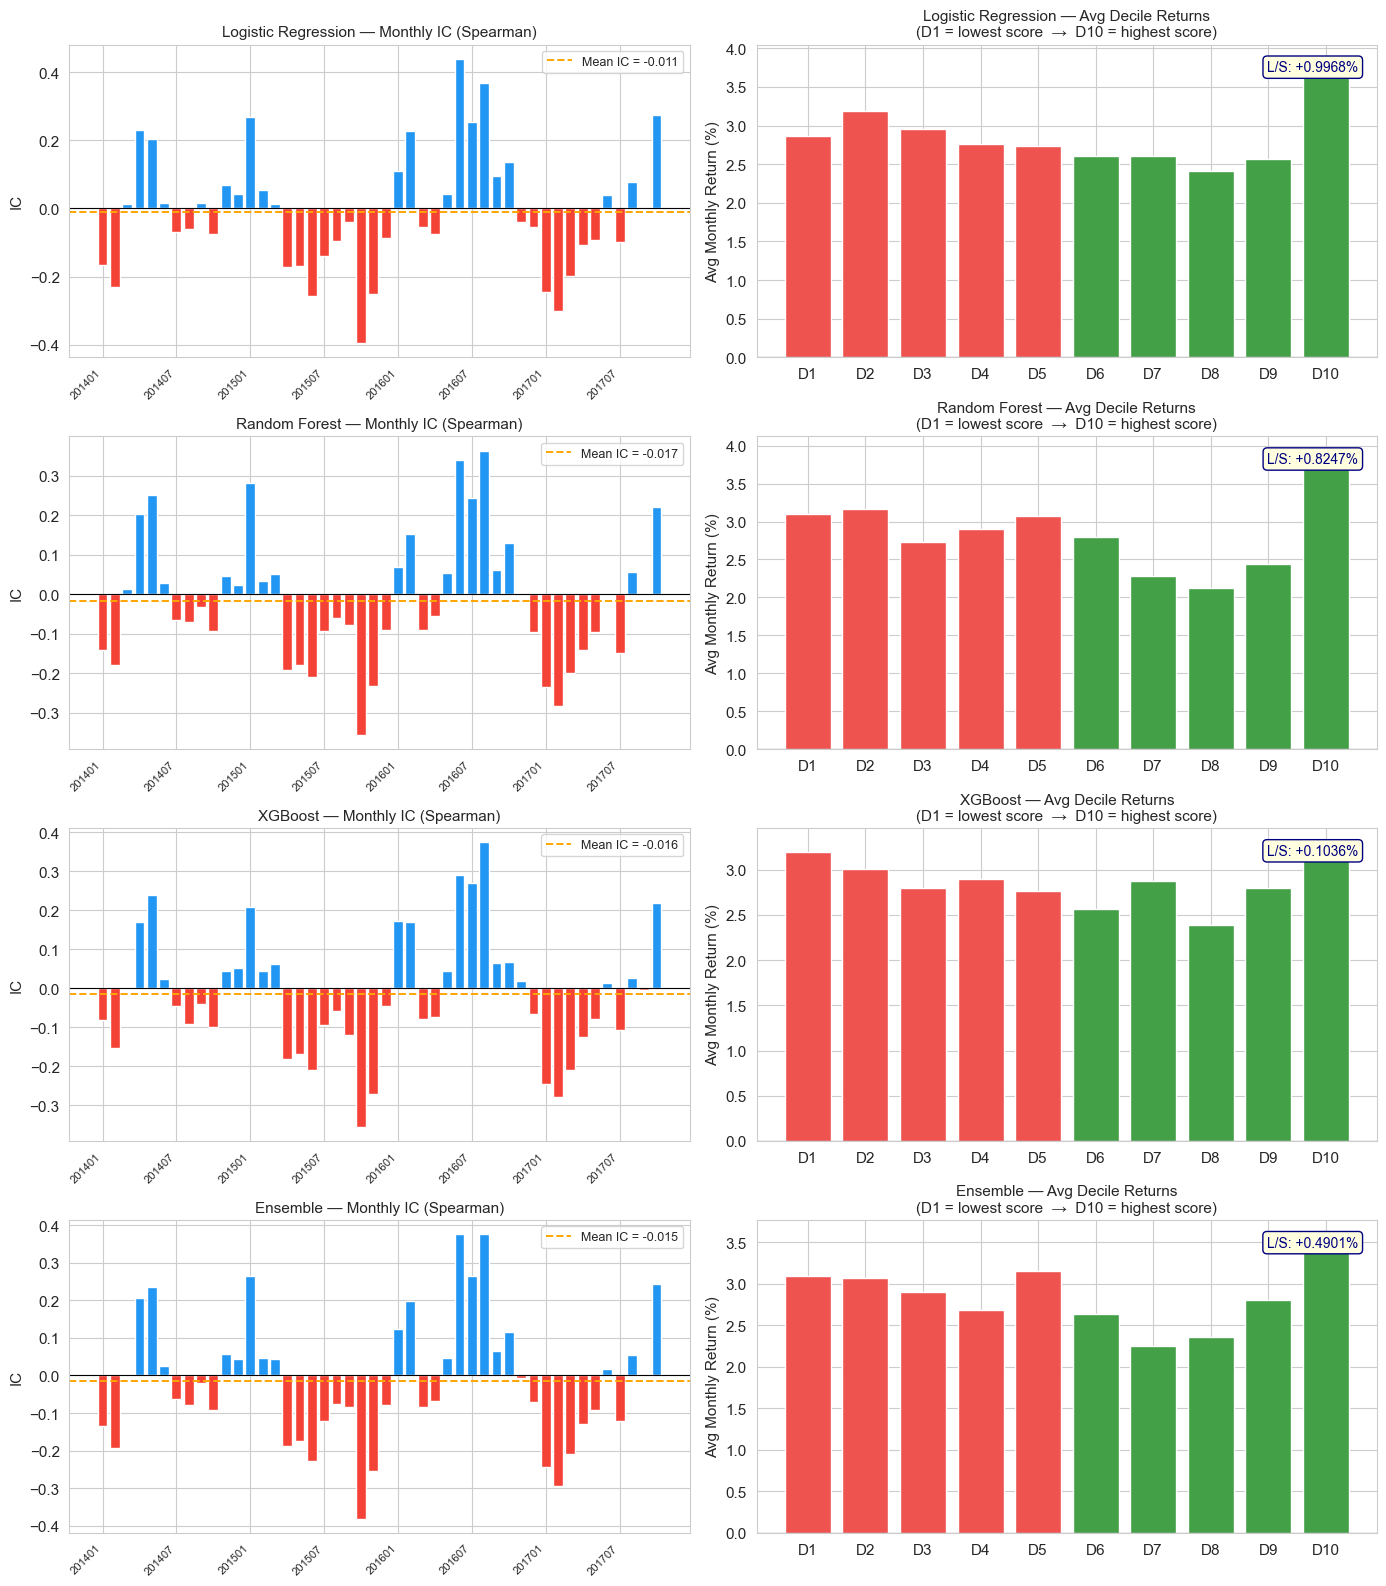

In [88]:
n_models  = len(models_portfolio)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2-D indexing works for a single model

print('=' * 62)
print('CROSS-SECTIONAL RANKING EVALUATION  (IC + Decile Analysis)')
print('=' * 62)

for i, (model_name, m_preds) in enumerate(models_portfolio):
    all_ics         = []  # list of (ym, ic) across all OOS years
    all_decile_rets = []  # list of 10-element arrays, one per year

    for year in ALL_EVAL_YEARS:
        if year not in m_preds:
            continue
        monthly_ics, avg_decile_rets = compute_ic_and_deciles(m_preds, year)
        all_ics.extend(monthly_ics)
        all_decile_rets.append(avg_decile_rets)

    ic_values   = [ic for _, ic in all_ics]
    avg_deciles = np.mean(all_decile_rets, axis=0)   # shape (10,)
    long_short  = avg_deciles[-1] - avg_deciles[0]   # D10 minus D1
    mean_ic     = float(np.mean(ic_values))

    print(f'  {model_name:<25}  Mean IC = {mean_ic:+.4f}   '
          f'Long-Short (D10-D1) = {long_short:+.4%}')

    # ── Left subplot: Monthly IC time series ─────────────────────────────
    ax_ic = axes[i, 0]
    bar_colors = ['#2196F3' if v >= 0 else '#F44336' for v in ic_values]
    ax_ic.bar(range(len(ic_values)), ic_values, color=bar_colors, width=0.8)
    ax_ic.axhline(0,       color='black',  lw=0.8)
    ax_ic.axhline(mean_ic, color='orange', lw=1.4, ls='--',
                  label=f'Mean IC = {mean_ic:+.3f}')
    # Show every 6th month label to avoid crowding
    tick_pos    = list(range(0, len(ic_values), 6))
    tick_labels = [str(all_ics[p][0]) for p in tick_pos]
    ax_ic.set_xticks(tick_pos)
    ax_ic.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax_ic.set_title(f'{model_name} — Monthly IC (Spearman)', fontsize=11)
    ax_ic.set_ylabel('IC')
    ax_ic.legend(fontsize=9)

    # ── Right subplot: Average decile returns ────────────────────────────
    ax_dec = axes[i, 1]
    decile_labels = [f'D{d + 1}' for d in range(10)]
    d_colors = ['#EF5350'] * 5 + ['#43A047'] * 5   # red = low half, green = high half
    ax_dec.bar(decile_labels, avg_deciles * 100, color=d_colors)
    ax_dec.axhline(0, color='black', lw=0.8)
    ax_dec.set_title(
        f'{model_name} — Avg Decile Returns\n'
        f'(D1 = lowest score  →  D10 = highest score)', fontsize=11)
    ax_dec.set_ylabel('Avg Monthly Return (%)')
    # Annotate long-short value in the corner
    ax_dec.annotate(
        f'L/S: {long_short:+.4%}',
        xy=(0.97, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10, color='navy',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='lightyellow', edgecolor='navy'))

print('=' * 62)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'ic_decile_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Step 10: Robustness Analysis

We examine two robustness dimensions:
1. **Feature importance** — which features drive each model's predictions.
2. **Portfolio cutoff sensitivity** — how excess return varies with the top-K% threshold.

10.1  Feature Importance


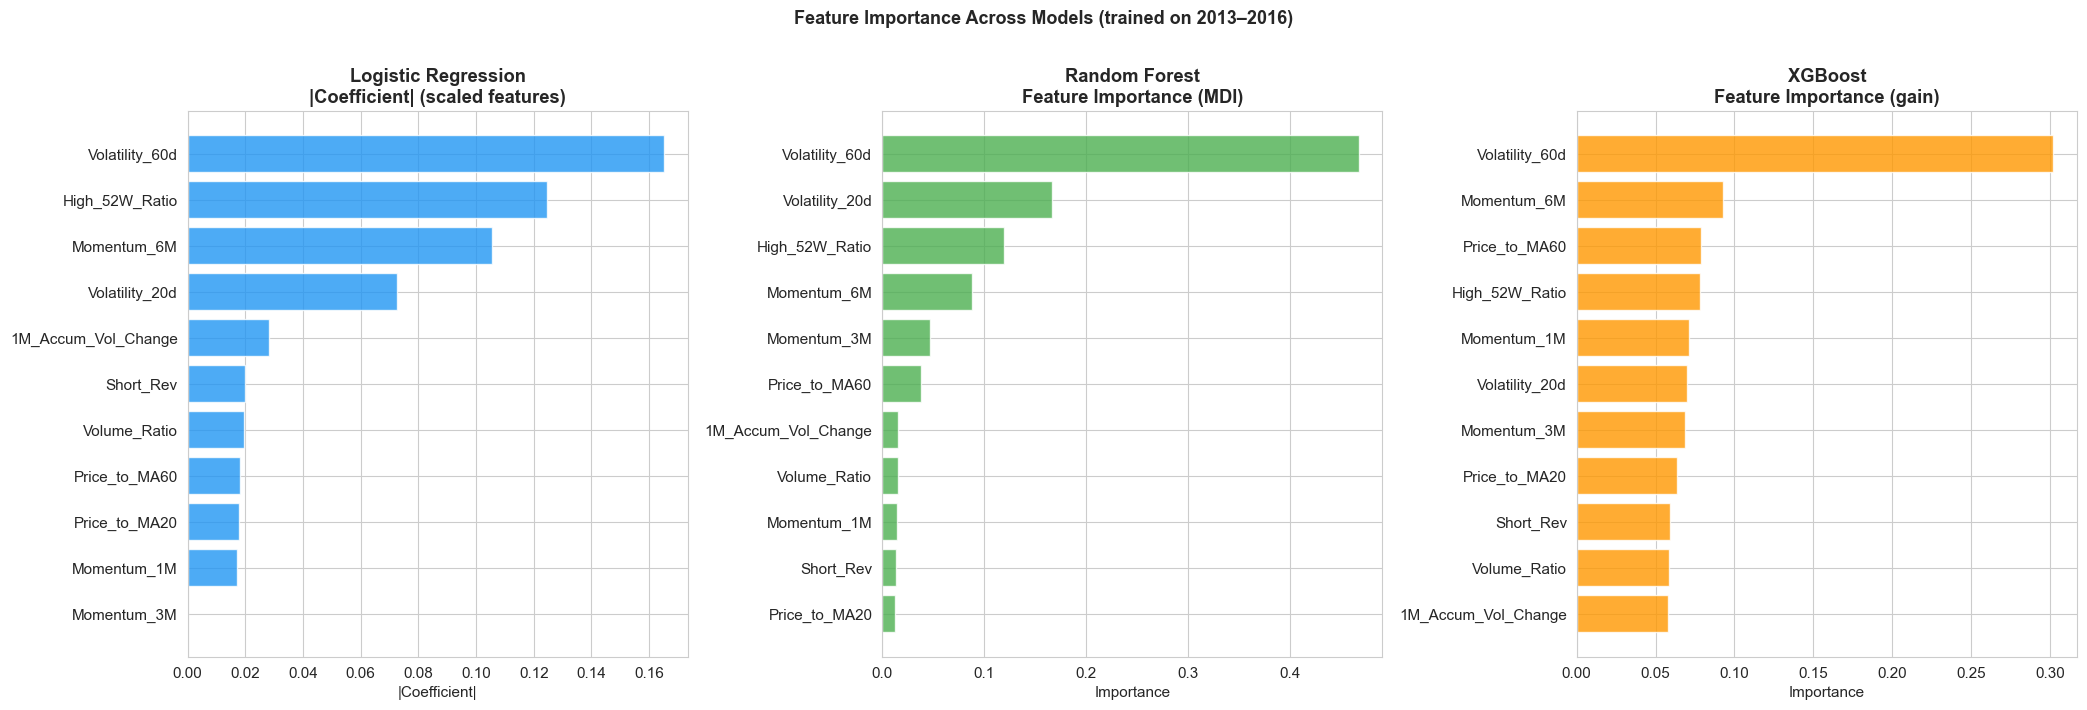

Saved: feature_importance.png


In [89]:
print('10.1  Feature Importance')
print('=' * 55)

n_imp_plots = 2 + int(XGB_AVAILABLE)
fig, axes = plt.subplots(1, n_imp_plots, figsize=(7 * n_imp_plots, 7))
if n_imp_plots == 1:
    axes = [axes]

# LR absolute coefficients
ax = axes[0]
coef  = np.abs(lr_final.coef_[0])
order = np.argsort(coef)
ax.barh([FEATURE_COLS[i] for i in order], coef[order], color='#2196F3', alpha=0.8)
ax.set_title('Logistic Regression\n|Coefficient| (scaled features)', fontweight='bold')
ax.set_xlabel('|Coefficient|')

# RF feature importance
ax = axes[1]
imp_rf   = rf_final.feature_importances_
order_rf = np.argsort(imp_rf)
ax.barh([FEATURE_COLS[i] for i in order_rf], imp_rf[order_rf], color='#4CAF50', alpha=0.8)
ax.set_title('Random Forest\nFeature Importance (MDI)', fontweight='bold')
ax.set_xlabel('Importance')

# XGB feature importance
if XGB_AVAILABLE:
    ax = axes[2]
    imp_xgb   = xgb_final.feature_importances_
    order_xgb = np.argsort(imp_xgb)
    ax.barh([FEATURE_COLS[i] for i in order_xgb], imp_xgb[order_xgb],
            color='#FF9800', alpha=0.8)
    ax.set_title('XGBoost\nFeature Importance (gain)', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Across Models (trained on 2013–2016)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

10.2  Portfolio Cutoff Sensitivity (Test Year 2017)


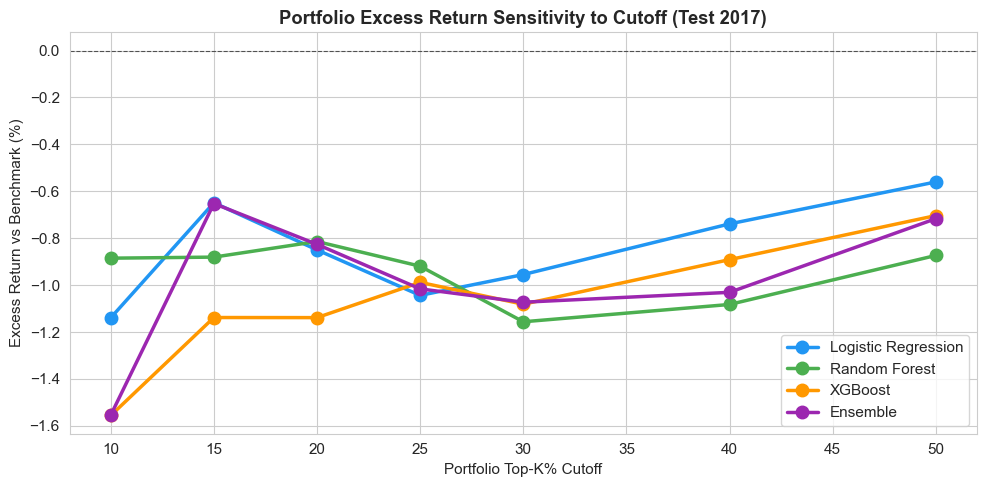

Saved: sensitivity.png

Excess Return vs Benchmark by Cutoff (Test 2017):
  Cutoff  Logistic Regres    Random Forest          XGBoost         Ensemble
----------------------------------------------------------------------------
     10%         -1.1393%         -0.8852%         -1.5559%         -1.5543%
     15%         -0.6488%         -0.8807%         -1.1382%         -0.6521%
     20%         -0.8499%         -0.8141%         -1.1387%         -0.8262%
     25%         -1.0438%         -0.9194%         -0.9883%         -1.0161%
     30%         -0.9550%         -1.1564%         -1.0816%         -1.0730%
     40%         -0.7391%         -1.0826%         -0.8914%         -1.0308%
     50%         -0.5602%         -0.8737%         -0.7037%         -0.7169%


In [90]:
print('10.2  Portfolio Cutoff Sensitivity (Test Year 2017)')
print('=' * 55)

cutoffs    = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sensitivity = {m[0]: [] for m in models_portfolio}

for topk in cutoffs:
    for model_name, preds_dict in models_portfolio:
        if TEST_YEAR in preds_dict:
            _, _, exc, _ = compute_portfolio_return(preds_dict, TEST_YEAR, topk)
            sensitivity[model_name].append(exc)
        else:
            sensitivity[model_name].append(np.nan)

s_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#607D8B']
fig, ax = plt.subplots(figsize=(10, 5))
for (model_name, _), color in zip(models_portfolio, s_colors):
    ax.plot([c * 100 for c in cutoffs],
            [v * 100 for v in sensitivity[model_name]],
            'o-', label=model_name, color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('Portfolio Top-K% Cutoff')
ax.set_ylabel('Excess Return vs Benchmark (%)')
ax.set_title(f'Portfolio Excess Return Sensitivity to Cutoff (Test {TEST_YEAR})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('sensitivity.png', bbox_inches='tight')
plt.show()
print('Saved: sensitivity.png')

print(f'\nExcess Return vs Benchmark by Cutoff (Test {TEST_YEAR}):')
hdr = f'{"Cutoff":>8}' + ''.join(f'  {m[0][:15]:>15}' for m in models_portfolio)
print(hdr)
print('-' * (8 + 17 * len(models_portfolio)))
for i, topk in enumerate(cutoffs):
    row = f'{topk:>8.0%}'
    for model_name, _ in models_portfolio:
        val = sensitivity[model_name][i]
        row += f'  {val:>15.4%}' if not np.isnan(val) else f'  {"N/A":>15}'
    print(row)

## Conclusion

This notebook implemented a complete machine learning pipeline for cross-sectional
stock selection on the S&P 500 universe.

**Key design decisions:**

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Formation period | Every calendar month (2013–2017) | ~12× more training data vs. single month |
| Features | 12 OHLCV-based indicators | Covers momentum, mean-reversion, volatility, volume |
| Feature normalisation | Cross-sectional z-score standardization (within month) | Removes time-series level shifts; preserves magnitude of differences |
| Target | 3-month forward cumulative return; Binary label: top 20% within each month | Horizon matches medium-term momentum; binary label gives broader training signal |
| Validation | Expanding-window by year | No look-ahead bias |
| Ensemble | Within-month rank-averaged LR + RF + XGBoost | Cross-sectional ranks are month-aligned; removes annual-level scale drift |

**Limitations & future work:**
- Features are purely price/volume based — fundamentals (P/E, earnings revisions) could add orthogonal signal.
- The sample covers a mostly bull-market period (2013–2017); out-of-sample robustness in bear markets is untested.
- Transaction costs, liquidity constraints, and rebalancing frequency are not modelled.
- More sophisticated ensembling (stacking, learning-to-rank) may further improve portfolio construction.